# 원본 노트북 링크:
- https://github.com/bcaitech1/p4-fr-sorry-math-but-love-you/tree/master

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.chdir('/content/drive/MyDrive/Colab Notebooks/졸업프로젝트/OMRiDA')

# Utils

- 그동안 imshow할때 aspect="auto"로 했어서 resize shape 관계없이 무조건 정방이미지로 시각화되었는데, resize 어떻게 되었는지 확인할 수 있게 aspect="equal"로 수정하고, 리사이즈 형상에 따라 성능영향차이가 생기는지 실험해보고자 함

In [ ]:
import matplotlib.pyplot as plt

def plot_dataset(images, labels, grid_width, grid_height, figure_width, figure_height, y_hats=None, vocab=None, wspace=0.5, hspace=1):

  # images, labels는 torch.tensor 타입으로 들어온다고 가정

  f, ax = plt.subplots(grid_height, grid_width, squeeze=False)
  f.set_size_inches(figure_width, figure_height)
  img_idx = 0

  eos_idx = 1

  for i in range(0, grid_height):
    for j in range(0, grid_width):
      image = images[img_idx].cpu().detach()
      label = labels[img_idx].cpu().detach()
      title_color = 'k'

      assert vocab is not None, "vocab을 입력하세요"

      label = label.tolist()
      label = label[1:label.index(eos_idx)]     # <sos>, <eos> 부분 제외 (EOS_IDX == 2) - <eos> 이전까지 뽑아서 <eos>이후 <pad> 부분도 제외되도록
      label = vocab.decode(label)               # list -> str

      if y_hats is not None:
            y_hat = y_hats[img_idx].cpu().detach().tolist()

            if eos_idx in y_hat:
                y_hat = y_hat[:y_hat.index(eos_idx)]   # <eos> 존재하면 <eos> 이후부분 (<eos> 및 <pad>) 무시

            y_hat = vocab.decode(y_hat)         # list -> str


            if label != y_hat:
                title_color = 'r'

            label = f'gt: {label}\npred:{y_hat}'

      ax[i][j].axis('off')
      ax[i][j].set_title(label, color=title_color)
      ax[i][j].imshow(image.permute(1,2,0).numpy(), aspect='equal', cmap='gray')
      img_idx += 1

    plt.subplots_adjust(left=0, bottom=0, right=2, top=2, wspace=wspace, hspace=hspace)
  plt.show()

In [ ]:
import editdistance

def exprate_k(preds, targets, k=0, eos_idx=1):

    # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

    # preds: (B, T-1)
    # targets: (B, T-1)

    assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

    cnt = 0
    for pred_seq, tgt_seq in zip(preds, targets):

        pred = pred_seq.tolist()
        tgt = tgt_seq.tolist()

        if eos_idx in pred:
            pred = pred[:pred.index(eos_idx)]

        if eos_idx in tgt:
            tgt = tgt[:tgt.index(eos_idx)]

        diff = editdistance.eval(pred, tgt)

        if diff<=k:
            cnt += 1

    return cnt / preds.shape[0]


def WER(preds, targets, eos_idx=1):

    # preds, targets에는 <sos>가 제거된 채로 함수인자로 들어온다고 가정

    # preds: (B, T-1)
    # targets: (B, T-1)

    assert preds.shape[0] == targets.shape[0], "예측 label과 정답 label의 배치 크기가 다릅니다"

    sum_wer = 0.0
    for pred_seq, tgt_seq in zip(preds, targets):

        pred = pred_seq.tolist()
        tgt = tgt_seq.tolist()

        if eos_idx in pred:
            pred = pred[:pred.index(eos_idx)]

        if eos_idx in tgt:
            tgt = tgt[:tgt.index(eos_idx)]

        distance = editdistance.eval(pred, tgt)
        length = len(tgt)

        sum_wer += (distance/length)

    return sum_wer / preds.shape[0]

In [ ]:
import os
import json
from pathlib import Path

def save_log(log_dict, save_path="log.json"):

    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    with open(save_path, "w", encoding="utf-8") as f:
        json.dump(log_dict, f, indent=2)
    print(f"저장 완료: {save_path}")


def plot_loss_curve(log_dict, metric="loss", overlap=False):

    assert metric in ["loss", "expr@0", "expr@1", "expr@2", "expr@3", "wer"], "metric은 loss, expr@0, expr@2, expr@3, wer 중 선택하여 입력해야합니다"

    if overlap==False:
        fig, axes = plt.subplots(2,1)

        fig.suptitle(f"{metric} Curve")

        # train
        train = log_dict["Train"]
        epochs = range(1, len(train)+1)

        train_metric = []
        for log in train:
            train_metric.append(log[metric])

        axes[0].plot(epochs, train_metric, marker='o')
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel(f"train {metric}")
        axes[0].grid(True)


        # valid
        valid = log_dict["Valid"]
        epochs = range(1, len(valid)+1)

        valid_metric = []
        for log in valid:
            valid_metric.append(log[metric])

        axes[1].plot(epochs, valid_metric, marker='o')
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel(f"valid {metric}")
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

    else:

        # train
        train = log_dict["Train"]
        epochs = range(1, len(train)+1)

        train_metric = []
        for log in train:
            train_metric.append(log[metric])

        plt.plot(epochs, train_metric, marker='o', label=f"Train {metric}")


        # valid
        valid = log_dict["Valid"]
        epochs = range(1, len(valid)+1)

        valid_metric = []
        for log in valid:
            valid_metric.append(log[metric])

        plt.plot(epochs, valid_metric, marker='o', label=f"Valid {metric}")

        plt.xlabel("Epoch")
        plt.ylabel(f"{metric}")
        plt.title(f"{metric} Curve")

        plt.legend()
        plt.grid(True)
        plt.show()

In [ ]:
import gspread

def save_test_result(experiment_name, val_dict):
    """ 실험결과를 구글스프레드시트에 저장 """

    gc = gspread.service_account(filename="service_account.json")
    sh = gc.open("test_results")

    # experiment_name이 스프레드시트의 각 sheet (윈도우)에 존재하는지 확인
    for metric in ["loss", "expr@0", "expr@1", "expr@2", "expr@3", "wer"]:
        worksheet = sh.worksheet(metric)

        try:
            row = worksheet.find(experiment_name).row

            # 이미 해당 실험이 과거에 진행된 경우가 있어 값들이 채워져있다면, 새로 실험하는 것이므로 해당 실험의 이전값들을 모든 sheet (윈도우)에 대해서 초기화해주고 시작
            range = f"B{row}:I{row}"
            val = [[""] * 8]
            worksheet.batch_update([{
                "range": range,
                "values": val
            }])

        except:
            last_row = len(worksheet.col_values(1))  # A열 중 값이 채워진 부분의 마지막 행번호
            worksheet.update_cell(last_row+1, 1, experiment_name)

    for metric in val_dict.keys():
        worksheet = sh.worksheet(metric)
        row = worksheet.find(experiment_name).row

        range = f"B{row}:I{row}"
        worksheet.batch_update([{
            "range": range,
            "values": [val_dict[metric]]
        }])

# Config (Global Parameters)
- 변경사항: optimizer 옵션을 config에 추가, weight_decay 적용

In [ ]:

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(DEVICE)

cuda


In [ ]:
import os, json
from datetime import datetime
import torch

epoch = int(input("epoch: "))
patience = int(input("patience: "))
bs = int(input("batch size: "))
optimizer_name = input("optimizer name (AdamW, adadelta, ...): ")

CFG = {
  "img_size": (384,384),
  "pad_idx": 112,
  "sos_idx": 0,
  "eos_idx": 1,

  "data": {
    "crohme": {
      "hme_img": "data/preprocessed/train/paired/crohme/hme_preprocessed",
      "pme_img": "data/preprocessed/train/paired/crohme/pme_preprocessed",
      "caption": "data/preprocessed/train/paired/crohme/caption.txt",
    },
    "im2latex": {
      "hme_img": "data/preprocessed/train/paired/im2latex/hme_img_train",
      "pme_img": "data/preprocessed/train/paired/im2latex/pme_img_train",
      "caption": "data/preprocessed/train/paired/im2latex/caption_train.txt",
    },
  },

  "model": {
    "vocab_size": 112,
    "encoder_emb_dim": 256,
    "decoder_emb_dim": 256,
    "decoder_hidden_dim": 512
  },

  "training": {
    "batch_size": bs,
    "epochs": epoch,
    "learning_rate": 0.001,   # 사실상 CosineAnnealingWarmupRestarts사용하면 이 부분의 학습률은 적용 안되는 셈임
    "match_weight": 0.2,      # DWAP에는 사용되지 않는 파라미터
    "optimizer": optimizer_name,
    "weight_decay": 1e-4,
    "grad_clip": 1.0,
    "tf_ratio": 0.5,
    "early_stop_patience": patience,
  },

  "testing": {"max_len": 150}
}

model_name = "NAVER winner (SWIN) - 384x384 resize, 3 channels"
scheduler_name = input("scheduler_name (CircularLRBeta, CosineAnnealingWarmup, ...): ")
min_lr = float(input("min_lr: "))
max_lr = float(input("max_lr: "))

experiment_name = f"{model_name}_epoch{CFG['training']['epochs']}_patience_{CFG['training']['early_stop_patience']}_bs{CFG['training']['batch_size']}_scheduler_{scheduler_name}_minLR_{min_lr}_maxLR_{max_lr}"

CFG["experiment_name"] = experiment_name

paths = {}
paths["best_ckpt"] = f"runs/{experiment_name}/best_model.pth"
paths["last_ckpt"] = f"runs/{experiment_name}/last_model.pth"
paths["train_log_json"] = f"runs/{experiment_name}/train_log.json"
paths["CFG"] = f"runs/{experiment_name}/config.json"

CFG["paths"] = paths

scheduler_info = {"name": scheduler_name}

CFG["scheduler"] = scheduler_info

epoch: 20
patience: 3
batch size: 16
optimizer name (AdamW, adadelta, ...): adamw
model_name: NAVER winner (SWIN) - 384x384 resize, 3 channels
scheduler_name (CircularLRBeta, CosineAnnealingWarmup, ...): circularlrbeta
min_lr: 5e-4
max_lr: 5e-4


In [ ]:
# 실험환경 디테일 config 저장

save_log(CFG, CFG["paths"]["CFG"])

저장 완료: runs/NAVER winner (SWIN) - 384x384 resize, 3 channels_epoch20_patience_3_bs16_scheduler_circularlrbeta_minLR_0.0005_maxLR_0.0005/config.json


In [ ]:
# 실험환경 폴더 생성

Path(os.path.join("runs", CFG["experiment_name"])).mkdir(parents=True, exist_ok=True)

# Custom Dataset

## Vocab

In [ ]:
# IM2LATEX 캡션 전처리용
def tokenize_formula(formula):
    ans = []
    tokens = formula.strip().split()

    for tok in tokens:
        chk = 0
        for sym in ["cm", "mm", "pt", "in", "ex", "em"]:
            if (tok[-2:] == sym) and tok[-3].isdigit():
                num, _ = tok.split(sym)
                num = ' '.join(num).split()
                ans.extend(num)
                ans.append(sym)
                chk = 1
                break

        if chk == 0:
            ans.append(tok)
    return ans


from typing import List

class Vocab:
  SOS_TOKEN = "<sos>"
  EOS_TOKEN = "<eos>"

  def __init__(self):
    self.default_tokens = [self.SOS_TOKEN, self.EOS_TOKEN]
    self.token2idx = {tok: idx for idx, tok in enumerate(self.default_tokens)}
    self.idx2token = self.default_tokens.copy()

  def __len__(self):
    return len(self.idx2token)

  def load_from_txt(self, path):
    with open(path, "r", encoding="latin1") as f:
      for line in f:
        token = line.strip()
        if token not in self.token2idx:
          idx = len(self.token2idx)
          self.token2idx[token] = idx
          self.idx2token.append(token)

  def encode(self, caption: str) -> List[int]:
    tokens = tokenize_formula(caption)
    return [self.token2idx[self.SOS_TOKEN]] + \
           [self.token2idx[token] for token in tokens] + \
           [self.token2idx[self.EOS_TOKEN]]

  def decode(self, token_ids: List[int]) -> str:
    return ' '.join([self.idx2token[token_id] for token_id in token_ids])

vocab = Vocab()
vocab.load_from_txt("vocab.txt")

In [ ]:
from torchvision import transforms
import torch
from PIL import ImageOps

def formula_collate_fn(batch):
    images = torch.stack([item["image"] for item in batch], dim=0)
    formulas = torch.nn.utils.rnn.pad_sequence(
        [item["formula"] for item in batch],
        batch_first=True,
        padding_value=CFG["pad_idx"]
    )
    return {"image": images, "formula": formulas}

In [ ]:
from pathlib import Path
from torch.utils.data import Dataset
from PIL import Image
import torch


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(CFG["img_size"]),
    transforms.Normalize(mean=[0.5], std=[0.5]),]
)


class FormulaDataset(Dataset):
  def __init__(self, img_path, labels_path, transform, vocab):
    self.img_path = img_path
    self.labels_path = labels_path
    self.transform = transform
    self.vocab = vocab

    self.samples = []
    with open(labels_path, "r", encoding="utf-8") as f:
      for line in f:
        parts = line.strip().split('\t')
        if len(parts)!=2:
          continue
        file_id, caption = parts

        if '.' not in file_id:
          file_id = f"{file_id}.png"

        img_path = os.path.join(self.img_path, file_id)
        if os.path.exists(img_path):
          self.samples.append((img_path, caption))

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    img_path, caption = self.samples[idx]
    img = Image.open(img_path).convert('RGB')#.convert('L')

    if self.transform:
      img = self.transform(img)

    caption_tokens = self.vocab.encode(caption)
    caption = torch.tensor(caption_tokens)

    return {"image": img, "formula": caption}

In [ ]:
train_path = CFG["data"]["crohme"]["hme_img"]
train_labels_path = CFG["data"]["crohme"]["caption"]

years = [2014, 2016, 2019]
crohme_test_paths = [f"data/preprocessed/test/hme/crohme/{year}/hme_img_preprocessed" for year in years]
crohme_test_labels_paths = [f"data/preprocessed/test/hme/crohme/{year}/caption.txt" for year in years]

cropme_test_paths = [f"data/preprocessed/test/pme/crohme/{year}/pme_img" for year in years]
cropme_test_labels_paths = [f"data/preprocessed/test/pme/crohme/{year}/caption.txt" for year in years]

im2latex_pme_path = "data/preprocessed/test/pme/im2latex/pme_img_test"
im2latex_pme_labels_path = "data/preprocessed/test/pme/im2latex/caption_test.txt"

im2latex_hme_path = "data/preprocessed/test/hme/im2latex/hme_img_test"
im2latex_hme_labels_path = "data/preprocessed/test/hme/im2latex/caption_test.txt"

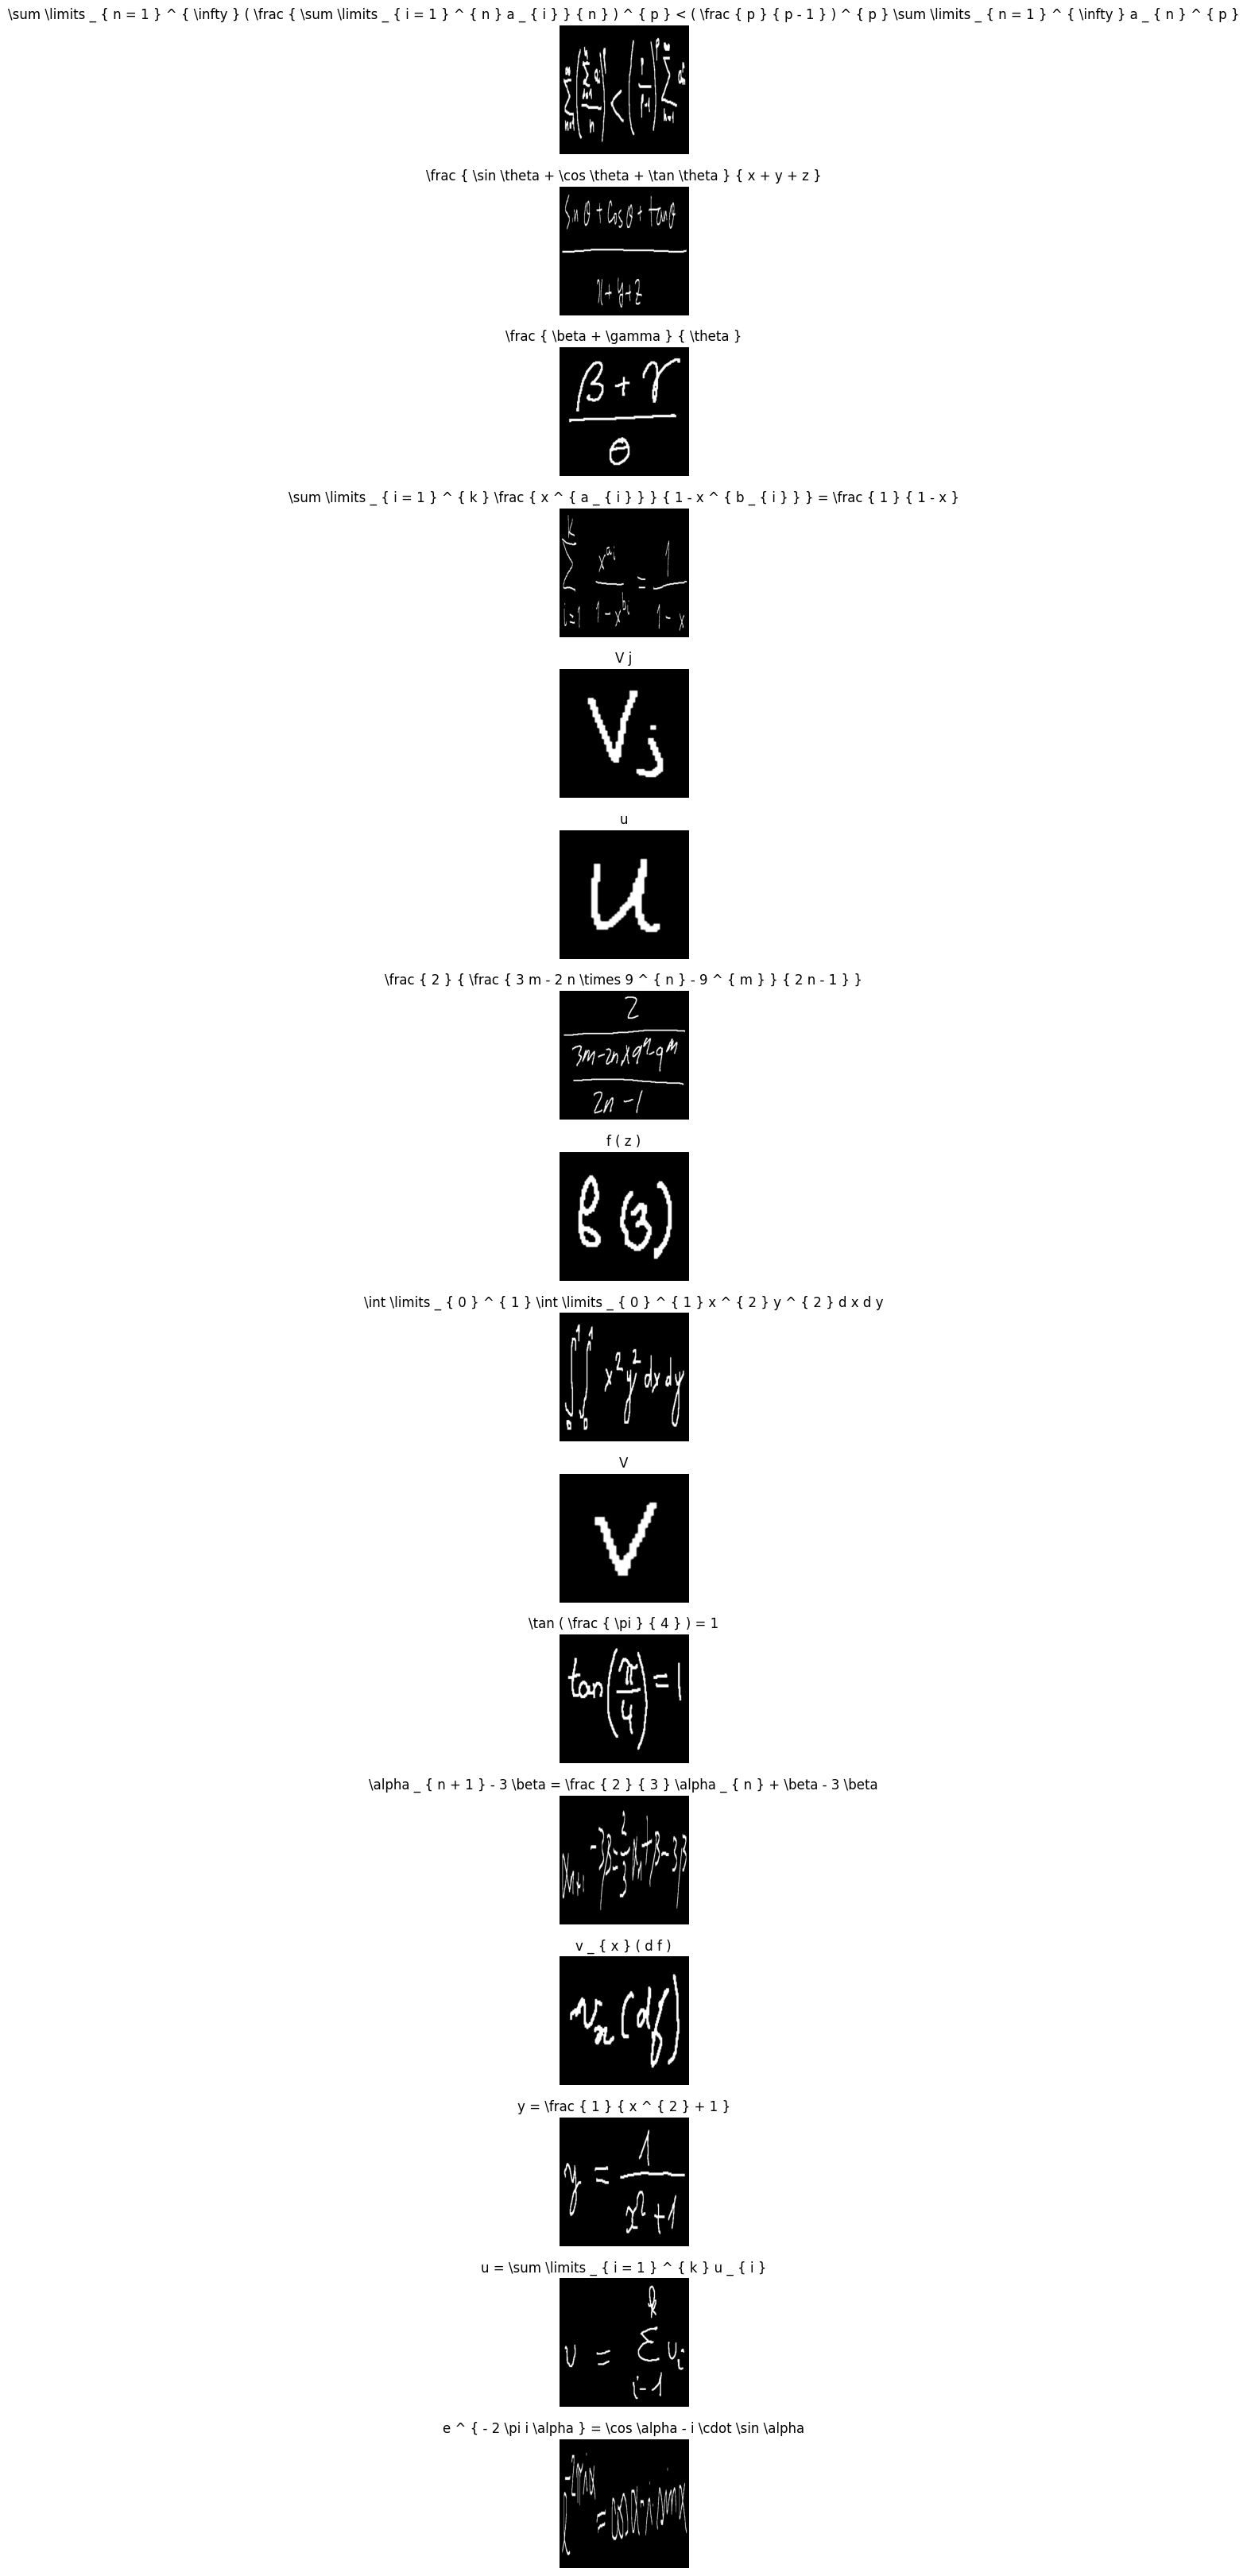

In [ ]:
batch_size = CFG["training"]["batch_size"]


# train valid split
trainset = FormulaDataset(train_path, train_labels_path, transform, vocab)
train_size = int(0.8 * len(trainset))
valid_size = len(trainset) - train_size
trainset, validset = torch.utils.data.random_split(trainset,[train_size, valid_size])


# loader

# train, valid
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, collate_fn=formula_collate_fn
)
validloader = torch.utils.data.DataLoader(
    validset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn
)

# test - CROHME
crohme_testset_2014 = FormulaDataset(crohme_test_paths[0], crohme_test_labels_paths[0], transform, vocab)
crohme_testset_2016 = FormulaDataset(crohme_test_paths[1], crohme_test_labels_paths[1], transform, vocab)
crohme_testset_2019 = FormulaDataset(crohme_test_paths[2], crohme_test_labels_paths[2], transform, vocab)

crohme_testloader_2014 = torch.utils.data.DataLoader(
    crohme_testset_2014, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

crohme_testloader_2016 = torch.utils.data.DataLoader(
    crohme_testset_2016, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

crohme_testloader_2019 = torch.utils.data.DataLoader(
    crohme_testset_2019, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

# test - CROPME
cropme_testset_2014 = FormulaDataset(cropme_test_paths[0], cropme_test_labels_paths[0], transform, vocab)
cropme_testset_2016 = FormulaDataset(cropme_test_paths[1], cropme_test_labels_paths[1], transform, vocab)
cropme_testset_2019 = FormulaDataset(cropme_test_paths[2], cropme_test_labels_paths[2], transform, vocab)

cropme_testloader_2014 = torch.utils.data.DataLoader(
    cropme_testset_2014, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

cropme_testloader_2016 = torch.utils.data.DataLoader(
    cropme_testset_2016, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

cropme_testloader_2019 = torch.utils.data.DataLoader(
    cropme_testset_2019, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)


# test - IM2LATEX (vocab 통일한 IM2LATEX의 caption 중 7:3으로 훈련 테스트 데이터 나누어 별도로 저장하여 구성하였음)

im2latex_hme_testset = FormulaDataset(im2latex_hme_path, im2latex_hme_labels_path, transform, vocab)
im2latex_hme_testloader = torch.utils.data.DataLoader(
    im2latex_hme_testset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)

im2latex_pme_testset = FormulaDataset(im2latex_pme_path, im2latex_pme_labels_path, transform, vocab)
im2latex_pme_testloader = torch.utils.data.DataLoader(
    im2latex_pme_testset, batch_size=1, shuffle=False, collate_fn=formula_collate_fn,
    num_workers=2, pin_memory=True, persistent_workers=True, prefetch_factor=2
)


# 데이터 확인

batch = next(iter(trainloader))
images = batch['image']
labels = batch['formula']
plot_dataset(images, labels, grid_width=1, grid_height=bs, figure_width=1, figure_height=bs, vocab=vocab, wspace=0.25, hspace=0.25)

# MODEL

## SwinTRN

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
import random
from timm.models.layers import DropPath, to_2tuple, trunc_normal_
from torch.utils.data import DataLoader
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class Mlp(nn.Module):
    def __init__(
        self,
        in_features,
        hidden_features=None,
        out_features=None,
        act_layer=nn.GELU,
        drop=0.0,
    ):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


def window_partition(x, window_size):
    """
    Args:
        x: (B, H, W, C)
        window_size (int): window size
    Returns:
        windows: (num_windows*B, window_size, window_size, C)
    """
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = (
        x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    )
    return windows


def window_reverse(windows, window_size, H, W):
    """
    Args:
        windows: (num_windows*B, window_size, window_size, C)
        window_size (int): Window size
        H (int): Height of image
        W (int): Width of image
    Returns:
        x: (B, H, W, C)
    """
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(
        B, H // window_size, W // window_size, window_size, window_size, -1
    )
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x


class WindowAttention(nn.Module):
    r"""Window based multi-head self attention (W-MSA) module with relative position bias.
    It supports both of shifted and non-shifted window.
    Args:
        dim (int): Number of input channels.
        window_size (tuple[int]): The height and width of the window.
        num_heads (int): Number of attention heads.
        qkv_bias (bool, optional):  If True, add a learnable bias to query, key, value. Default: True
        qk_scale (float | None, optional): Override default qk scale of head_dim ** -0.5 if set
        attn_drop (float, optional): Dropout ratio of attention weight. Default: 0.0
        proj_drop (float, optional): Dropout ratio of output. Default: 0.0
    """

    def __init__(
        self,
        dim,
        window_size,
        num_heads,
        qkv_bias=True,
        qk_scale=None,
        attn_drop=0.0,
        proj_drop=0.0,
    ):

        super().__init__()
        self.dim = dim
        self.window_size = window_size  # Wh, Ww
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = qk_scale or head_dim ** -0.5

        # define a parameter table of relative position bias
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2 * window_size[0] - 1) * (2 * window_size[1] - 1), num_heads)
        )  # 2*Wh-1 * 2*Ww-1, nH

        # get pair-wise relative position index for each token inside the window
        coords_h = torch.arange(self.window_size[0])
        coords_w = torch.arange(self.window_size[1])
        coords = torch.stack(torch.meshgrid([coords_h, coords_w]))  # 2, Wh, Ww
        coords_flatten = torch.flatten(coords, 1)  # 2, Wh*Ww
        relative_coords = (
            coords_flatten[:, :, None] - coords_flatten[:, None, :]
        )  # 2, Wh*Ww, Wh*Ww
        relative_coords = relative_coords.permute(
            1, 2, 0
        ).contiguous()  # Wh*Ww, Wh*Ww, 2
        relative_coords[:, :, 0] += self.window_size[0] - 1  # shift to start from 0
        relative_coords[:, :, 1] += self.window_size[1] - 1
        relative_coords[:, :, 0] *= 2 * self.window_size[1] - 1
        relative_position_index = relative_coords.sum(-1)  # Wh*Ww, Wh*Ww
        self.register_buffer("relative_position_index", relative_position_index)

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

        trunc_normal_(self.relative_position_bias_table, std=0.02)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, mask=None):
        """
        Args:
            x: input features with shape of (num_windows*B, N, C)
            mask: (0/-inf) mask with shape of (num_windows, Wh*Ww, Wh*Ww) or None
        """
        B_, N, C = x.shape
        qkv = (
            self.qkv(x)
            .reshape(B_, N, 3, self.num_heads, C // self.num_heads)
            .permute(2, 0, 3, 1, 4)
        )
        q, k, v = (
            qkv[0],
            qkv[1],
            qkv[2],
        )  # make torchscript happy (cannot use tensor as tuple)

        q = q * self.scale
        attn = q @ k.transpose(-2, -1)

        relative_position_bias = self.relative_position_bias_table[
            self.relative_position_index.view(-1)
        ].view(
            self.window_size[0] * self.window_size[1],
            self.window_size[0] * self.window_size[1],
            -1,
        )  # Wh*Ww,Wh*Ww,nH
        relative_position_bias = relative_position_bias.permute(
            2, 0, 1
        ).contiguous()  # nH, Wh*Ww, Wh*Ww
        attn = attn + relative_position_bias.unsqueeze(0)

        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N) + mask.unsqueeze(
                1
            ).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)
            attn = self.softmax(attn)
        else:
            attn = self.softmax(attn)

        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

    def extra_repr(self) -> str:
        return f"dim={self.dim}, window_size={self.window_size}, num_heads={self.num_heads}"

    def flops(self, N):
        # calculate flops for 1 window with token length of N
        flops = 0
        # qkv = self.qkv(x)
        flops += N * self.dim * 3 * self.dim
        # attn = (q @ k.transpose(-2, -1))
        flops += self.num_heads * N * (self.dim // self.num_heads) * N
        #  x = (attn @ v)
        flops += self.num_heads * N * N * (self.dim // self.num_heads)
        # x = self.proj(x)
        flops += N * self.dim * self.dim
        return flops


class SwinTransformerBlock(nn.Module):
    r"""Swin Transformer Block.
    Args:
        dim (int): Number of input channels.
        input_resolution (tuple[int]): Input resulotion.
        num_heads (int): Number of attention heads.
        window_size (int): Window size.
        shift_size (int): Shift size for SW-MSA.
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim.
        qkv_bias (bool, optional): If True, add a learnable bias to query, key, value. Default: True
        qk_scale (float | None, optional): Override default qk scale of head_dim ** -0.5 if set.
        drop (float, optional): Dropout rate. Default: 0.0
        attn_drop (float, optional): Attention dropout rate. Default: 0.0
        drop_path (float, optional): Stochastic depth rate. Default: 0.0
        act_layer (nn.Module, optional): Activation layer. Default: nn.GELU
        norm_layer (nn.Module, optional): Normalization layer.  Default: nn.LayerNorm
    """

    def __init__(
        self,
        dim,
        input_resolution,
        num_heads,
        window_size=7,
        shift_size=0,
        mlp_ratio=4.0,
        qkv_bias=True,
        qk_scale=None,
        drop=0.0,
        attn_drop=0.0,
        drop_path=0.0,
        act_layer=nn.GELU,
        norm_layer=nn.LayerNorm,
    ):
        super().__init__()
        self.dim = dim
        self.input_resolution = input_resolution
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size
        self.mlp_ratio = mlp_ratio
        if min(self.input_resolution) <= self.window_size:
            # if window size is larger than input resolution, we don't partition windows
            self.shift_size = 0
            self.window_size = min(self.input_resolution)
        assert (
            0 <= self.shift_size < self.window_size
        ), "shift_size must in 0-window_size"

        self.norm1 = norm_layer(dim)
        self.attn = WindowAttention(
            dim,
            window_size=to_2tuple(self.window_size),
            num_heads=num_heads,
            qkv_bias=qkv_bias,
            qk_scale=qk_scale,
            attn_drop=attn_drop,
            proj_drop=drop,
        )

        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(
            in_features=dim,
            hidden_features=mlp_hidden_dim,
            act_layer=act_layer,
            drop=drop,
        )

        if self.shift_size > 0:
            # calculate attention mask for SW-MSA
            H, W = self.input_resolution
            img_mask = torch.zeros((1, H, W, 1))  # 1 H W 1
            h_slices = (
                slice(0, -self.window_size),
                slice(-self.window_size, -self.shift_size),
                slice(-self.shift_size, None),
            )
            w_slices = (
                slice(0, -self.window_size),
                slice(-self.window_size, -self.shift_size),
                slice(-self.shift_size, None),
            )
            cnt = 0
            for h in h_slices:
                for w in w_slices:
                    img_mask[:, h, w, :] = cnt
                    cnt += 1

            mask_windows = window_partition(
                img_mask, self.window_size
            )  # nW, window_size, window_size, 1
            mask_windows = mask_windows.view(-1, self.window_size * self.window_size)
            attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
            attn_mask = attn_mask.masked_fill(
                attn_mask != 0, float(-100.0)
            ).masked_fill(attn_mask == 0, float(0.0))
        else:
            attn_mask = None

        self.register_buffer("attn_mask", attn_mask)

    def forward(self, x):
        H, W = self.input_resolution
        B, L, C = x.shape
        assert L == H * W, "input feature has wrong size"

        shortcut = x
        x = self.norm1(x)
        x = x.view(B, H, W, C)

        # cyclic shift
        if self.shift_size > 0:
            shifted_x = torch.roll(
                x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2)
            )
        else:
            shifted_x = x

        # partition windows
        x_windows = window_partition(
            shifted_x, self.window_size
        )  # nW*B, window_size, window_size, C
        x_windows = x_windows.view(
            -1, self.window_size * self.window_size, C
        )  # nW*B, window_size*window_size, C

        # W-MSA/SW-MSA
        attn_windows = self.attn(
            x_windows, mask=self.attn_mask
        )  # nW*B, window_size*window_size, C

        # merge windows
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        shifted_x = window_reverse(attn_windows, self.window_size, H, W)  # B H' W' C

        # reverse cyclic shift
        if self.shift_size > 0:
            x = torch.roll(
                shifted_x, shifts=(self.shift_size, self.shift_size), dims=(1, 2)
            )
        else:
            x = shifted_x
        x = x.view(B, H * W, C)

        # FFN
        x = shortcut + self.drop_path(x)
        x = x + self.drop_path(self.mlp(self.norm2(x)))

        return x

    def extra_repr(self) -> str:
        return (
            f"dim={self.dim}, input_resolution={self.input_resolution}, num_heads={self.num_heads}, "
            f"window_size={self.window_size}, shift_size={self.shift_size}, mlp_ratio={self.mlp_ratio}"
        )

    def flops(self):
        flops = 0
        H, W = self.input_resolution
        # norm1
        flops += self.dim * H * W
        # W-MSA/SW-MSA
        nW = H * W / self.window_size / self.window_size
        flops += nW * self.attn.flops(self.window_size * self.window_size)
        # mlp
        flops += 2 * H * W * self.dim * self.dim * self.mlp_ratio
        # norm2
        flops += self.dim * H * W
        return flops


class PatchMerging(nn.Module):
    r"""Patch Merging Layer.
    Args:
        input_resolution (tuple[int]): Resolution of input feature.
        dim (int): Number of input channels.
        norm_layer (nn.Module, optional): Normalization layer.  Default: nn.LayerNorm
    """

    def __init__(self, input_resolution, dim, norm_layer=nn.LayerNorm):
        super().__init__()
        self.input_resolution = input_resolution
        self.dim = dim
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = norm_layer(4 * dim)

    def forward(self, x):
        """
        x: B, H*W, C
        """
        H, W = self.input_resolution
        B, L, C = x.shape
        assert L == H * W, "input feature has wrong size"
        assert H % 2 == 0 and W % 2 == 0, f"x size ({H}*{W}) are not even."

        x = x.view(B, H, W, C)

        x0 = x[:, 0::2, 0::2, :]  # B H/2 W/2 C
        x1 = x[:, 1::2, 0::2, :]  # B H/2 W/2 C
        x2 = x[:, 0::2, 1::2, :]  # B H/2 W/2 C
        x3 = x[:, 1::2, 1::2, :]  # B H/2 W/2 C
        x = torch.cat([x0, x1, x2, x3], -1)  # B H/2 W/2 4*C
        x = x.view(B, -1, 4 * C)  # B H/2*W/2 4*C

        x = self.norm(x)
        x = self.reduction(x)

        return x

    def extra_repr(self) -> str:
        return f"input_resolution={self.input_resolution}, dim={self.dim}"

    def flops(self):
        H, W = self.input_resolution
        flops = H * W * self.dim
        flops += (H // 2) * (W // 2) * 4 * self.dim * 2 * self.dim
        return flops


class BasicLayer(nn.Module):
    """A basic Swin Transformer layer for one stage.
    Args:
        dim (int): Number of input channels.
        input_resolution (tuple[int]): Input resolution.
        depth (int): Number of blocks.
        num_heads (int): Number of attention heads.
        window_size (int): Local window size.
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim.
        qkv_bias (bool, optional): If True, add a learnable bias to query, key, value. Default: True
        qk_scale (float | None, optional): Override default qk scale of head_dim ** -0.5 if set.
        drop (float, optional): Dropout rate. Default: 0.0
        attn_drop (float, optional): Attention dropout rate. Default: 0.0
        drop_path (float | tuple[float], optional): Stochastic depth rate. Default: 0.0
        norm_layer (nn.Module, optional): Normalization layer. Default: nn.LayerNorm
        downsample (nn.Module | None, optional): Downsample layer at the end of the layer. Default: None
        use_checkpoint (bool): Whether to use checkpointing to save memory. Default: False.
    """

    def __init__(
        self,
        dim,
        input_resolution,
        depth,
        num_heads,
        window_size,
        mlp_ratio=4.0,
        qkv_bias=True,
        qk_scale=None,
        drop=0.0,
        attn_drop=0.0,
        drop_path=0.0,
        norm_layer=nn.LayerNorm,
        downsample=None
    ):

        super().__init__()
        self.dim = dim
        self.input_resolution = input_resolution
        self.depth = depth

        # build blocks
        self.blocks = nn.ModuleList(
            [
                SwinTransformerBlock(
                    dim=dim,
                    input_resolution=input_resolution,
                    num_heads=num_heads,
                    window_size=window_size,
                    shift_size=0 if (i % 2 == 0) else window_size // 2,
                    mlp_ratio=mlp_ratio,
                    qkv_bias=qkv_bias,
                    qk_scale=qk_scale,
                    drop=drop,
                    attn_drop=attn_drop,
                    drop_path=drop_path[i]
                    if isinstance(drop_path, list)
                    else drop_path,
                    norm_layer=norm_layer,
                )
                for i in range(depth)
            ]
        )

        # patch merging layer
        if downsample is not None:
            self.downsample = downsample(
                input_resolution, dim=dim, norm_layer=norm_layer
            )
        else:
            self.downsample = None

    def forward(self, x):
        for blk in self.blocks:
            x = blk(x)
        if self.downsample is not None:
            x = self.downsample(x)
        return x

    def extra_repr(self) -> str:
        return f"dim={self.dim}, input_resolution={self.input_resolution}, depth={self.depth}"

    def flops(self):
        flops = 0
        for blk in self.blocks:
            flops += blk.flops()
        if self.downsample is not None:
            flops += self.downsample.flops()
        return flops


class PatchEmbed(nn.Module):
    r"""Image to Patch Embedding
    Args:
        img_size (int): Image size.  Default: 224.
        patch_size (int): Patch token size. Default: 4.
        in_chans (int): Number of input image channels. Default: 3.
        embed_dim (int): Number of linear projection output channels. Default: 96.
        norm_layer (nn.Module, optional): Normalization layer. Default: None
    """

    def __init__(
        self, img_size=224, patch_size=4, in_chans=3, embed_dim=96, norm_layer=None
    ):
        super().__init__()
        img_size = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)
        patches_resolution = [
            img_size[0] // patch_size[0],
            img_size[1] // patch_size[1],
        ]
        self.img_size = img_size
        self.patch_size = patch_size
        self.patches_resolution = patches_resolution
        self.num_patches = patches_resolution[0] * patches_resolution[1]

        self.in_chans = in_chans
        self.embed_dim = embed_dim

        self.proj = nn.Conv2d(
            in_chans, embed_dim, kernel_size=patch_size, stride=patch_size
        )
        if norm_layer is not None:
            self.norm = norm_layer(embed_dim)
        else:
            self.norm = None

    def forward(self, x):
        B, C, H, W = x.shape
        # FIXME look at relaxing size constraints
        assert (
            H == self.img_size[0] and W == self.img_size[1]
        ), f"Input image size ({H}*{W}) doesn't match model ({self.img_size[0]}*{self.img_size[1]})."
        x = self.proj(x).flatten(2).transpose(1, 2)  # B Ph*Pw C
        if self.norm is not None:
            x = self.norm(x)
        return x

    def flops(self):
        Ho, Wo = self.patches_resolution
        flops = (
            Ho
            * Wo
            * self.embed_dim
            * self.in_chans
            * (self.patch_size[0] * self.patch_size[1])
        )
        if self.norm is not None:
            flops += Ho * Wo * self.embed_dim
        return flops


class SwinTransformer(nn.Module):
    r"""Swin Transformer
        A PyTorch impl of : `Swin Transformer: Hierarchical Vision Transformer using Shifted Windows`  -
          https://arxiv.org/pdf/2103.14030
    Args:
        img_size (int | tuple(int)): Input image size. Default 224
        patch_size (int | tuple(int)): Patch size. Default: 4
        in_chans (int): Number of input image channels. Default: 3
        num_classes (int): Number of classes for classification head. Default: 1000
        embed_dim (int): Patch embedding dimension. Default: 96
        depths (tuple(int)): Depth of each Swin Transformer layer.
        num_heads (tuple(int)): Number of attention heads in different layers.
        window_size (int): Window size. Default: 7
        mlp_ratio (float): Ratio of mlp hidden dim to embedding dim. Default: 4
        qkv_bias (bool): If True, add a learnable bias to query, key, value. Default: True
        qk_scale (float): Override default qk scale of head_dim ** -0.5 if set. Default: None
        drop_rate (float): Dropout rate. Default: 0
        attn_drop_rate (float): Attention dropout rate. Default: 0
        drop_path_rate (float): Stochastic depth rate. Default: 0.1
        norm_layer (nn.Module): Normalization layer. Default: nn.LayerNorm.
        ape (bool): If True, add absolute position embedding to the patch embedding. Default: False
        patch_norm (bool): If True, add normalization after patch embedding. Default: True
        use_checkpoint (bool): Whether to use checkpointing to save memory. Default: False
    """

    def __init__(
        self,
        img_size=224,
        patch_size=4,
        in_chans=3,
        num_classes=1000,
        embed_dim=96,
        depths=[2, 2, 6, 2],
        num_heads=[3, 6, 12, 24],
        window_size=7,
        mlp_ratio=4.0,
        qkv_bias=True,
        qk_scale=None,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        drop_path_rate=0.1,
        norm_layer=nn.LayerNorm,
        ape=False,
        patch_norm=True,
        **kwargs,
    ):
        super().__init__()
        # m = timm.create_model('swin_base_patch4_window12_384_in22k', pretrained=True) # JUST FOR TRAIN
        self.num_classes = num_classes
        self.num_layers = len(depths)
        self.embed_dim = embed_dim
        self.ape = ape
        self.patch_norm = patch_norm
        self.num_features = int(embed_dim * 2 ** (self.num_layers - 1))
        self.mlp_ratio = mlp_ratio

        # split image into non-overlapping patches
        self.patch_embed = PatchEmbed(
            img_size=img_size,
            patch_size=patch_size,
            in_chans=in_chans,
            embed_dim=embed_dim,
            norm_layer=norm_layer if self.patch_norm else None,
        )
        num_patches = self.patch_embed.num_patches
        patches_resolution = self.patch_embed.patches_resolution
        self.patches_resolution = patches_resolution

        # absolute position embedding
        if self.ape:
            self.absolute_pos_embed = nn.Parameter(
                torch.zeros(1, num_patches, embed_dim)
            )
            trunc_normal_(self.absolute_pos_embed, std=0.02)

        self.pos_drop = nn.Dropout(p=drop_rate)

        # stochastic depth
        dpr = [
            x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))
        ]  # stochastic depth decay rule

        # build layers
        self.layers = nn.ModuleList()
        for i_layer in range(self.num_layers):
            layer = BasicLayer(
                dim=int(embed_dim * 2 ** i_layer),
                input_resolution=(
                    patches_resolution[0] // (2 ** i_layer),
                    patches_resolution[1] // (2 ** i_layer),
                ),
                depth=depths[i_layer],
                num_heads=num_heads[i_layer],
                window_size=window_size,
                mlp_ratio=self.mlp_ratio,
                qkv_bias=qkv_bias,
                qk_scale=qk_scale,
                drop=drop_rate,
                attn_drop=attn_drop_rate,
                drop_path=dpr[sum(depths[:i_layer]) : sum(depths[: i_layer + 1])],
                norm_layer=norm_layer,
                downsample=PatchMerging if (i_layer < self.num_layers - 1) else None
            )
            self.layers.append(layer)

        self.norm = norm_layer(self.num_features)
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.head = (
            nn.Linear(self.num_features, num_classes)
            if num_classes > 0
            else nn.Identity()
        )

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=0.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    @torch.jit.ignore
    def no_weight_decay(self):
        return {"absolute_pos_embed"}

    @torch.jit.ignore
    def no_weight_decay_keywords(self):
        return {"relative_position_bias_table"}

    def forward_features(self, x):
        x = self.patch_embed(x)
        if self.ape:
            x = x + self.absolute_pos_embed
        x = self.pos_drop(x)

        for layer in self.layers:
            x = layer(x)

        x = self.norm(x)  # B L C
        # x = self.avgpool(x.transpose(1, 2))  # B C 1
        # x = torch.flatten(x, 1)
        return x

    def forward(self, x):
        x = self.forward_features(x)
        # x = self.head(x)
        return x

    def flops(self):
        flops = 0
        flops += self.patch_embed.flops()
        for i, layer in enumerate(self.layers):
            flops += layer.flops()
        flops += (
            self.num_features
            * self.patches_resolution[0]
            * self.patches_resolution[1]
            // (2 ** self.num_layers)
        )
        flops += self.num_features * self.num_classes
        return flops


class ScaledDotProductAttention(nn.Module):
    def __init__(self, temperature, dropout=0.1):
        super(ScaledDotProductAttention, self).__init__()

        self.temperature = temperature
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, q, k, v, mask=None):

        attn = torch.matmul(q, k.transpose(2, 3)) / self.temperature
        if mask is not None:
            attn = attn.masked_fill(mask=mask, value=float("-inf"))
        attn = torch.softmax(attn, dim=-1)
        attn = self.dropout(attn)
        out = torch.matmul(attn, v)
        return out, attn


class MultiHeadAttention(nn.Module):
    def __init__(self, q_channels, k_channels, head_num=8, dropout=0.1):
        super(MultiHeadAttention, self).__init__()

        self.q_channels = q_channels
        self.k_channels = k_channels
        self.head_dim = q_channels // head_num
        self.head_num = head_num

        self.q_linear = nn.Linear(q_channels, self.head_num * self.head_dim)
        self.k_linear = nn.Linear(k_channels, self.head_num * self.head_dim)
        self.v_linear = nn.Linear(k_channels, self.head_num * self.head_dim)
        self.attention = ScaledDotProductAttention(
            temperature=(self.head_num * self.head_dim) ** 0.5, dropout=dropout
        )
        self.out_linear = nn.Linear(self.head_num * self.head_dim, q_channels)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, q, k, v, mask=None):
        b, q_len, k_len, v_len = q.size(0), q.size(1), k.size(1), v.size(1)
        q = (
            self.q_linear(q)
            .view(b, q_len, self.head_num, self.head_dim)
            .transpose(1, 2)
        )
        k = (
            self.k_linear(k)
            .view(b, k_len, self.head_num, self.head_dim)
            .transpose(1, 2)
        )
        v = (
            self.v_linear(v)
            .view(b, v_len, self.head_num, self.head_dim)
            .transpose(1, 2)
        )

        if mask is not None:
            mask = mask.unsqueeze(1)

        out, attn = self.attention(q, k, v, mask=mask)
        out = (
            out.transpose(1, 2)
            .contiguous()
            .view(b, q_len, self.head_num * self.head_dim)
        )
        out = self.out_linear(out)
        out = self.dropout(out)

        return out


class Feedforward(nn.Module):
    def __init__(self, filter_size=2048, hidden_dim=512, dropout=0.1):
        super(Feedforward, self).__init__()

        self.layers = nn.Sequential(
            nn.Linear(hidden_dim, filter_size, True),
            nn.ReLU(True),
            nn.Dropout(p=dropout),
            nn.Linear(filter_size, hidden_dim, True),
            nn.ReLU(True),
            nn.Dropout(p=dropout),
        )

    def forward(self, input):
        return self.layers(input)


class TransformerDecoderLayer(nn.Module):
    def __init__(self, input_size, src_size, filter_size, head_num, dropout_rate=0.2):
        super(TransformerDecoderLayer, self).__init__()

        self.self_attention_layer = MultiHeadAttention(
            q_channels=input_size,
            k_channels=input_size,
            head_num=head_num,
            dropout=dropout_rate,
        )
        self.self_attention_norm = nn.LayerNorm(normalized_shape=input_size)

        self.attention_layer = MultiHeadAttention(
            q_channels=input_size,
            k_channels=src_size,
            head_num=head_num,
            dropout=dropout_rate,
        )
        self.attention_norm = nn.LayerNorm(normalized_shape=input_size)

        self.feedforward_layer = Feedforward(
            filter_size=filter_size, hidden_dim=input_size
        )
        self.feedforward_norm = nn.LayerNorm(normalized_shape=input_size)

    def forward(self, tgt, tgt_prev, src, tgt_mask):

        if tgt_prev == None:  # Train
            att = self.self_attention_layer(tgt, tgt, tgt, tgt_mask)
            out = self.self_attention_norm(att + tgt)

            att = self.attention_layer(out, src, src)
            out = self.attention_norm(att + out)

            ff = self.feedforward_layer(out)
            out = self.feedforward_norm(ff + out)
        else:
            tgt_prev = torch.cat([tgt_prev, tgt], 1)
            att = self.self_attention_layer(tgt, tgt_prev, tgt_prev, tgt_mask)
            out = self.self_attention_norm(att + tgt)

            att = self.attention_layer(out, src, src)
            out = self.attention_norm(att + out)

            ff = self.feedforward_layer(out)
            out = self.feedforward_norm(ff + out)
        return out


class PositionEncoder1D(nn.Module):
    def __init__(self, in_channels, max_len=500, dropout=0.1):
        super(PositionEncoder1D, self).__init__()

        self.position_encoder = self.generate_encoder(in_channels, max_len)
        self.position_encoder = self.position_encoder.unsqueeze(0)
        self.dropout = nn.Dropout(p=dropout)

    def generate_encoder(self, in_channels, max_len):
        pos = torch.arange(max_len).float().unsqueeze(1)

        i = torch.arange(in_channels).float().unsqueeze(0)
        angle_rates = 1 / torch.pow(10000, (2 * (i // 2)) / in_channels)

        position_encoder = pos * angle_rates
        position_encoder[:, 0::2] = torch.sin(position_encoder[:, 0::2])
        position_encoder[:, 1::2] = torch.cos(position_encoder[:, 1::2])

        return position_encoder

    def forward(self, x, point=-1):
        if point == -1:
            out = x + self.position_encoder[:, : x.size(1), :].to(x.get_device())
            out = self.dropout(out)
        else:
            out = x + self.position_encoder[:, point, :].unsqueeze(1).to(x.get_device())
        return out


class TransformerDecoder(nn.Module):
    def __init__(
        self,
        num_classes,
        src_dim,
        hidden_dim,
        filter_dim,
        head_num,
        dropout_rate,
        pad_id,
        st_id,
        layer_num=1,
        checkpoint=None,
    ):
        super(TransformerDecoder, self).__init__()

        self.embedding = nn.Embedding(num_classes + 1, hidden_dim)
        self.hidden_dim = hidden_dim
        self.filter_dim = filter_dim
        self.num_classes = num_classes
        self.layer_num = layer_num

        self.pos_encoder = PositionEncoder1D(
            in_channels=hidden_dim, dropout=dropout_rate
        )

        self.attention_layers = nn.ModuleList(
            [
                TransformerDecoderLayer(
                    hidden_dim, src_dim, filter_dim, head_num, dropout_rate
                )
                for _ in range(layer_num)
            ]
        )
        self.generator = nn.Linear(hidden_dim, num_classes)

        self.pad_id = pad_id
        self.st_id = st_id

    def pad_mask(self, text):
        pad_mask = text == self.pad_id
        pad_mask[:, 0] = False
        pad_mask = pad_mask.unsqueeze(1)

        return pad_mask

    def order_mask(self, length):
        order_mask = torch.triu(torch.ones(length, length), diagonal=1).bool()
        order_mask = order_mask.unsqueeze(0).to(device)
        return order_mask

    def text_embedding(self, texts):
        tgt = self.embedding(texts)
        tgt *= math.sqrt(tgt.size(2))

        return tgt

    def forward(
        self, src, text, is_train=True, batch_max_length=50, teacher_forcing_ratio=1.0
    ):

        if is_train and random.random() < teacher_forcing_ratio:
            tgt = self.text_embedding(text)
            tgt = self.pos_encoder(tgt)
            tgt_mask = self.pad_mask(text) | self.order_mask(text.size(1))
            for layer in self.attention_layers:
                tgt = layer(tgt, None, src, tgt_mask)
            out = self.generator(tgt)
        else:
            out = []
            num_steps = batch_max_length - 1
            target = (
                torch.LongTensor(src.size(0)).fill_(self.st_id).to(device)
            )  # [START] token
            features = [None] * self.layer_num

            for t in range(num_steps):
                target = target.unsqueeze(1)
                tgt = self.text_embedding(target)
                tgt = self.pos_encoder(tgt, point=t)
                tgt_mask = self.order_mask(t + 1)
                tgt_mask = tgt_mask[:, -1].unsqueeze(1)  # [1, (l+1)]
                for l, layer in enumerate(self.attention_layers):
                    tgt = layer(tgt, features[l], src, tgt_mask)
                    features[l] = (
                        tgt if features[l] == None else torch.cat([features[l], tgt], 1)
                    )

                _out = self.generator(tgt)  # [b, 1, c]
                target = torch.argmax(_out[:, -1:, :], dim=-1)  # [b, 1]
                target = target.squeeze(1)  # [b]
                out.append(_out)

            out = torch.stack(out, dim=1).to(device)  # [b, max length, 1, class length]
            out = out.squeeze(2)  # [b, max length, class length]

        return out


class SWIN(nn.Module):
    def __init__(self):
        super(SWIN, self).__init__()

        self.encoder = SwinTransformer(img_size=CFG["img_size"][0], patch_size=4, in_chans=3,
            embed_dim=128, depths=[2, 2, 18, 2], num_heads=[4, 8, 16, 32],
            window_size=12, mlp_ratio=4.,num_classes=21841,
            drop_path_rate=0.5, ape=True,)

        state_dict = torch.hub.load_state_dict_from_url('https://github.com/SwinTransformer/storage/releases/download/v1.0.0/swin_base_patch4_window12_384_22k.pth')
        self.encoder.load_state_dict(state_dict['model'], strict=False)

        self.decoder = TransformerDecoder(
            num_classes=CFG["model"]["vocab_size"],
            src_dim=1024,
            hidden_dim=512,
            filter_dim=512,
            head_num=8,
            dropout_rate=0.1,
            pad_id=CFG["pad_idx"],
            st_id=CFG["sos_idx"],
            layer_num=4,
        )
        self.criterion = nn.CrossEntropyLoss(
            ignore_index=CFG["pad_idx"]
        )

    def forward(self, input, expected, is_train, teacher_forcing_ratio):
        enc_result = self.encoder(input)
        dec_result = self.decoder(
            enc_result,
            expected[:, :-1],
            is_train,
            expected.size(1),
            teacher_forcing_ratio,
        )
        return dec_result


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:


# class SWIN_encoder(nn.Module):
#     def __init__(
#         self
#     ):  # NOTE: 수정 - CrossEntropyLoss 제거
#         super(SWIN_encoder, self).__init__()
#         self.encoder = SwinTransformer(
#             img_size=384,
#             patch_size=4,
#             in_chans=3,
#             embed_dim=128,
#             depths=[2, 2, 18, 2],
#             num_heads=[4, 8, 16, 32],
#             window_size=12,
#             mlp_ratio=4.0,
#             num_classes=21841,
#             drop_path_rate=0.5,
#             ape=True,
#         )

#     # NOTE: 수정
#     def forward(self, input):
#         enc_result = self.encoder(input)
#         return enc_result


# class SWIN_decoder(nn.Module):
#     def __init__(
#         self
#     ):  # NOTE: 수정 - CrossEntropyLoss 제거
#         super(SWIN_decoder, self).__init__()
#         self.decoder = TransformerDecoder(
#             num_classes=CFG["model"]["vocab_size"],
#             src_dim=1024,
#             hidden_dim=512,
#             filter_dim=512,
#             head_num=8,
#             dropout_rate=0.1,
#             pad_id=CFG["pad_idx"],
#             st_id=CFG["sos_idx"],
#             layer_num=4,
#         )
#         self.step_idx = 0
#         self.features = [None] * self.decoder.layer_num

#     def forward(self, input, expected, is_train, teacher_forcing_ratio):
#         dec_result = self.decoder(
#             input,
#             expected[:, :-1],
#             is_train,
#             expected.size(1),
#             teacher_forcing_ratio,
#         )
#         return dec_result

#     # NOTE: 수정 - reset_state가 ensemble.py에서 발생함 & num_step을 외부(ensemble.py)에서 통제함
#     def step_forward(self, src, target):
#         target = target.unsqueeze(1)  # b, 1
#         tgt = self.decoder.text_embedding(target)  # b, t+1, 128
#         tgt = self.decoder.pos_encoder(tgt, point=self.step_idx)  # b, t+1, 128
#         tgt_mask = self.decoder.order_mask(self.step_idx + 1)  # 1,t+1,t+1
#         tgt_mask = tgt_mask[:, -1].unsqueeze(1)  # [1,1,t+1]
#         for l, layer in enumerate(self.decoder.attention_layers):
#             tgt = layer(tgt, self.features[l], src, tgt_mask)
#             self.features[l] = (
#                 tgt
#                 if self.features[l] == None
#                 else torch.cat([self.features[l], tgt], 1)
#             )
#         _out = self.decoder.generator(tgt)  # [b, 1, c]
#         self.step_idx += 1
#         return _out

#     def reset_status(self):
#         self.step_idx = 0
#         self.features = [None] * self.decoder.layer_num

#     def beam_search(
#         self,
#         input: torch.Tensor,
#         data_loader: DataLoader,
#         topk: int = 1,
#         beam_width: int = 5,
#         max_sequence: int = 230,
#     ):
#         # 사용할 토큰
#         sos_token_id = CFG["sos_idx"]
#         eos_token_id = CFG["eos_idx"]
#         pad_token_id = CFG["pad_idx"]

#         batch_size = len(input)
#         src = self.encoder(input)  # [B, HxW, C]

#         decoded_batch = []
#         with torch.no_grad():

#             # 문장 단위 생성
#             for data_idx in range(batch_size):

#                 end_nodes = []
#                 number_required = min((topk + 1), topk - len(end_nodes))  # 최대 생성 횟수

#                 # 빔서치 과정 상 역추적을 위한 우선순위큐 선언
#                 nodes = PriorityQueue()

#                 # 시작 토큰 초기화
#                 current_src = src[data_idx, :, :].unsqueeze(0)  # [B=1, HxW, C]
#                 current_input = torch.LongTensor([sos_token_id])  # [B=1]
#                 current_hidden = [None] * self.decoder.layer_num
#                 node = BeamSearchNode(
#                     hidden_state=deepcopy(current_hidden),
#                     prev_node=None,
#                     token_id=deepcopy(current_input),  # [1]
#                     log_prob=0,
#                     length=1,  # NOTE: P.E에 사용
#                 )
#                 score = -node.eval()

#                 # 최대힙: 확률 높은 토큰을 추출하기 위함
#                 nodes.put((score, node))

#                 num_steps = 0
#                 while True:
#                     if num_steps >= (max_sequence - 1) * beam_width:
#                         break

#                     # 최대확률샘플 추출/제거, score: 로그확률, n: BeamSearchNode
#                     score, n = nodes.get()
#                     current_input = n.token_id  # [B=1]
#                     current_hidden = n.hidden_state
#                     current_point = n.len - 1  # P.E 적용 시 활용

#                     # 종료 토큰이 생성될 경우(종료 토큰 & 이전 노드 존재)
#                     if n.token_id.item() == eos_token_id and n.prev_node != None:
#                         end_nodes.append((score, n))
#                         if len(end_nodes) >= number_required:
#                             break
#                         else:
#                             continue

#                     current_input = current_input.unsqueeze(1)  # [B=1, 1]

#                     tgt = self.decoder.text_embedding(
#                         texts=current_input.to(input.get_device())
#                     )  # [B=1, 1, HIDDEN]
#                     tgt = self.decoder.pos_encoder(
#                         x=tgt, point=current_point
#                     )  # [B=1, 1, HIDDEN]
#                     tgt_mask = self.decoder.order_mask(
#                         length=current_point + 1
#                     )  # [B=1, LEN, LEN]
#                     tgt_mask = tgt_mask[:, -1].unsqueeze(1)  # [B=1, 1, LEN]

#                     # 어텐션 레이어 통과
#                     for l, layer in enumerate(self.decoder.attention_layers):
#                         tgt = layer(
#                             tgt=tgt,  # [B=1, 1, HIDDEN]
#                             tgt_prev=current_hidden[l],
#                             src=current_src,
#                             tgt_mask=tgt_mask,
#                         )  # [1, 1, HIDDEN]

#                         # Hidden state 갱신
#                         # 첫 state: [1, 1, HIDDEN]
#                         # 이후: [B=1, 1, HIDDEN] -> [B=1, 2, HIDDEN] -> [B=1, 3, HIDDEN] -> ...
#                         current_hidden[l] = (
#                             tgt
#                             if current_hidden[l] is None
#                             else torch.cat([current_hidden[l], tgt], dim=1)
#                         )

#                     # 확률화하기 전 모델의 로짓
#                     prob_step = self.decoder.generator(tgt)  # [B=1, 1, VOCAB_SIZE]

#                     # 모델의 로짓을  확률화
#                     log_prob_step = F.log_softmax(
#                         prob_step, dim=-1
#                     )  # [B=1, 1, VOCAB_SIZE]
#                     log_prob, indices = torch.topk(log_prob_step, beam_width)

#                     # 다음 state에 활용할 {beam_width}개 후보 노드를 우선순위큐에 삽입
#                     next_nodes = []
#                     for new_k in range(beam_width):
#                         decoded_t = indices[:, :, new_k].squeeze(0)
#                         log_p = log_prob[:, :, new_k].item()

#                         node = BeamSearchNode(
#                             hidden_state=deepcopy(current_hidden),
#                             prev_node=n,
#                             token_id=deepcopy(decoded_t),
#                             log_prob=n.logp + log_p,
#                             length=n.len + 1,
#                         )
#                         score = -node.eval()
#                         next_nodes.append((score, node))

#                     for i in range(len(next_nodes)):
#                         score, next_node = next_nodes[i]
#                         nodes.put((score, next_node))

#                     num_steps += beam_width

#                 # <EOS> 토큰이 한번도 등장하지 않았을 경우 - 최대 확률 노드
#                 if len(end_nodes) == 0:
#                     end_nodes = [nodes.get() for _ in range(topk)]

#                 utterances = []
#                 for score, n in sorted(
#                     end_nodes, key=operator.itemgetter(0)
#                 ):  # 가장 마지막 노드에서 역추적
#                     utterance = []
#                     utterance.append(n.token_id.item())
#                     # back trace
#                     while n.prev_node != None:
#                         n = n.prev_node
#                         utterance.append(n.token_id.item())

#                     utterance = utterance[::-1]  # 뒤집기
#                     utterances.append(utterance)

#                 if topk == 1:
#                     decoded_batch.append(utterances[0])
#                 else:
#                     decoded_batch.append(utterances)

#         # id_to_string의 입력에 맞게 텐서로 변경
#         outputs = []
#         for decoded_sample in decoded_batch:
#             if len(decoded_sample) < max_sequence:
#                 num_pads = max_sequence - len(decoded_sample)
#                 decoded_sample += [pad_token_id] * num_pads
#             elif len(decoded_sample) > max_sequence:
#                 decoded_sample = decoded_sample[:max_sequence]
#             outputs.append(decoded_sample)
#         outputs = torch.tensor(outputs)

#         return outputs

# Train


In [ ]:
def train(model, train_loader, valid_loader=None, criterion=None, optimizer=None, scheduler=None, device="cuda"):

    EPOCHS = CFG["training"]["epochs"]
    GRAD_CLIP = CFG["training"]["grad_clip"]
    eos_idx = CFG["eos_idx"]

    best_loss = float("inf")
    patience = 0

    log_dict = {"Train": [], "Valid": []}

    save_best = Path(CFG["paths"]["best_ckpt"])
    save_last = Path(CFG["paths"]["last_ckpt"])

    try:
        for epoch in range(1, EPOCHS+1):
            model.train()
            total_loss = 0.0
            total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
            total_wer = 0.0
            num_batches = 0
            lr_history = []

            loop = tqdm(train_loader, desc=f"[Train] Epoch {epoch}/{EPOCHS}", leave=True)

            for batch in loop:
                optimizer.zero_grad()

                imgs = batch["image"].to(device)
                labels = batch["formula"].to(device)

                pred = model(imgs, labels, is_train=True, teacher_forcing_ratio=CFG["training"]["tf_ratio"])  # (B,T-1,V)
                labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

                loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
                pred_tokens = pred.argmax(dim=-1)       # (B,T-1,V) -> (B,T-1)

                loss.backward()

                if GRAD_CLIP and GRAD_CLIP > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

                optimizer.step()

                with torch.no_grad():
                    expr_0 = exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx)
                    expr_1 = exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx)
                    expr_2 = exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx)
                    expr_3 = exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx)
                    wer = WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx)

                total_loss += float(loss.item())
                total_expr_0 += float(expr_0)
                total_expr_1 += float(expr_1)
                total_expr_2 += float(expr_2)
                total_expr_3 += float(expr_3)
                total_wer += float(wer)
                num_batches += 1

                loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer, lr=optimizer.param_groups[0]['lr'])

                if scheduler is not None:
                    scheduler.step()

                lr_history.append(optimizer.param_groups[0]['lr'])

            avg_loss = total_loss / num_batches
            avg_expr_0 = total_expr_0 / num_batches
            avg_expr_1 = total_expr_1 / num_batches
            avg_expr_2 = total_expr_2 / num_batches
            avg_expr_3 = total_expr_3 / num_batches
            avg_wer = total_wer / num_batches


            print(f"\n[Train Epoch {epoch}] Loss: {avg_loss:.4f}, "
                f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

            log_dict["Train"].append({
                "epoch": epoch,
                "loss": avg_loss,
                "expr@0": avg_expr_0,
                "expr@1": avg_expr_1,
                "expr@2": avg_expr_2,
                "expr@3": avg_expr_3,
                "wer": avg_wer,
                "lr": lr_history
            })

            # 에포크 끝날때마다 스케줄려 업데이트 하는 경우
            # if scheduler:
            #     if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            #         scheduler.step(avg_loss)
            #     else:
            #         scheduler.step()



            # validation
            model.eval()
            total_loss = 0.0
            total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
            total_wer = 0.0
            num_batches = 0

            loop = tqdm(valid_loader, desc=f"[Valid] Epoch {epoch}/{EPOCHS}", leave=True)

            for batch in loop:

                imgs = batch["image"].to(device)
                labels = batch["formula"].to(device)

                pred = model(imgs, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
                labels = labels[:, 1:]                  # sos 제외: (B,T) => (B,T-1)

                loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
                pred_tokens = pred.argmax(dim=-1)              # (B,T-1,V) -> (B,T-1)

                expr_0 = float(exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx))
                expr_1 = float(exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx))
                expr_2 = float(exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx))
                expr_3 = float(exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx))
                wer = float(WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx))

                total_loss += float(loss.item())
                total_expr_0 += expr_0
                total_expr_1 += expr_1
                total_expr_2 += expr_2
                total_expr_3 += expr_3
                total_wer += wer
                num_batches += 1

                loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer)

            avg_loss = total_loss / num_batches
            avg_expr_0 = total_expr_0 / num_batches
            avg_expr_1 = total_expr_1 / num_batches
            avg_expr_2 = total_expr_2 / num_batches
            avg_expr_3 = total_expr_3 / num_batches
            avg_wer = total_wer / num_batches


            print(f"\n[Valid Epoch {epoch}] Loss: {avg_loss:.4f}, "
                f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

            log_dict["Valid"].append({
                "epoch": epoch,
                "loss": avg_loss,
                "expr@0": avg_expr_0,
                "expr@1": avg_expr_1,
                "expr@2": avg_expr_2,
                "expr@3": avg_expr_3,
                "wer": avg_wer
            })

            torch.save({"model": model.state_dict()}, save_last)

            if epoch == 1 or avg_loss < best_loss:
                best_loss = avg_loss
                patience = 0
                save_best.parent.mkdir(parents=True, exist_ok=True)
                torch.save({"model": model.state_dict()}, save_best)
                print("Best model saved.")

            else:
                patience += 1
                print(f"Early Stopping count: {patience}/{CFG['training']['early_stop_patience']}")
                if patience >= CFG["training"]["early_stop_patience"]:
                    print(f"Early stopping at epoch {epoch}")
                    break

            print()

    except KeyboardInterrupt:
        print("\n Training interrupted by user. Returning current results...")
        torch.save({"model": model.state_dict()}, save_last)  # 현재 상태 저장

    finally:
        return log_dict, best_loss

In [ ]:
def train(model, train_loader, valid_loader=None, criterion=None, optimizer=None, scheduler=None, device="cuda"):

    EPOCHS = CFG["training"]["epochs"]
    GRAD_CLIP = CFG["training"]["grad_clip"]
    eos_idx = CFG["eos_idx"]

    best_loss = float("inf")
    patience = 0

    log_dict = {"Train": [], "Valid": []}

    save_best = Path(CFG["paths"]["best_ckpt"])
    save_last = Path(CFG["paths"]["last_ckpt"])

    for epoch in range(1, EPOCHS+1):
        model.train()
        total_loss = 0.0
        total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
        total_wer = 0.0
        num_batches = 0
        lr_history = []

        loop = tqdm(train_loader, desc=f"[Train] Epoch {epoch}/{EPOCHS}", leave=True)

        for batch in loop:
            optimizer.zero_grad()

            imgs = batch["image"].to(device)
            labels = batch["formula"].to(device)

            pred = model(imgs, labels, is_train=True, teacher_forcing_ratio=CFG["training"]["tf_ratio"])  # (B,T-1,V)
            labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

            loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
            pred_tokens = pred.argmax(dim=-1)       # (B,T-1,V) -> (B,T-1)

            loss.backward()

            if GRAD_CLIP and GRAD_CLIP > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

            optimizer.step()

            with torch.no_grad():
                expr_0 = exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx)
                expr_1 = exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx)
                expr_2 = exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx)
                expr_3 = exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx)
                wer = WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx)

            total_loss += float(loss.item())
            total_expr_0 += float(expr_0)
            total_expr_1 += float(expr_1)
            total_expr_2 += float(expr_2)
            total_expr_3 += float(expr_3)
            total_wer += float(wer)
            num_batches += 1

            loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer, lr=optimizer.param_groups[0]['lr'])

            if scheduler is not None:
                scheduler.step()

            lr_history.append(optimizer.param_groups[0]['lr'])

        avg_loss = total_loss / num_batches
        avg_expr_0 = total_expr_0 / num_batches
        avg_expr_1 = total_expr_1 / num_batches
        avg_expr_2 = total_expr_2 / num_batches
        avg_expr_3 = total_expr_3 / num_batches
        avg_wer = total_wer / num_batches


        print(f"\n[Train Epoch {epoch}] Loss: {avg_loss:.4f}, "
            f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

        log_dict["Train"].append({
            "epoch": epoch,
            "loss": avg_loss,
            "expr@0": avg_expr_0,
            "expr@1": avg_expr_1,
            "expr@2": avg_expr_2,
            "expr@3": avg_expr_3,
            "wer": avg_wer,
            "lr": lr_history
        })

        # 에포크 끝날때마다 스케줄려 업데이트 하는 경우
        # if scheduler:
        #     if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        #         scheduler.step(avg_loss)
        #     else:
        #         scheduler.step()



        # validation
        model.eval()
        total_loss = 0.0
        total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
        total_wer = 0.0
        num_batches = 0

        loop = tqdm(valid_loader, desc=f"[Valid] Epoch {epoch}/{EPOCHS}", leave=True)

        for batch in loop:

            imgs = batch["image"].to(device)
            labels = batch["formula"].to(device)

            pred = model(imgs, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
            labels = labels[:, 1:]                  # sos 제외: (B,T) => (B,T-1)

            loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
            pred_tokens = pred.argmax(dim=-1)              # (B,T-1,V) -> (B,T-1)

            expr_0 = float(exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx))
            expr_1 = float(exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx))
            expr_2 = float(exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx))
            expr_3 = float(exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx))
            wer = float(WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx))

            total_loss += float(loss.item())
            total_expr_0 += expr_0
            total_expr_1 += expr_1
            total_expr_2 += expr_2
            total_expr_3 += expr_3
            total_wer += wer
            num_batches += 1

            loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer)

        avg_loss = total_loss / num_batches
        avg_expr_0 = total_expr_0 / num_batches
        avg_expr_1 = total_expr_1 / num_batches
        avg_expr_2 = total_expr_2 / num_batches
        avg_expr_3 = total_expr_3 / num_batches
        avg_wer = total_wer / num_batches


        print(f"\n[Valid Epoch {epoch}] Loss: {avg_loss:.4f}, "
            f"Expr@0: {avg_expr_0:.4f}, Expr@1: {avg_expr_1:.4f}, Expr@2: {avg_expr_2:.4f}, Expr@3: {avg_expr_3:.4f}, WER: {avg_wer:.4f}")

        log_dict["Valid"].append({
            "epoch": epoch,
            "loss": avg_loss,
            "expr@0": avg_expr_0,
            "expr@1": avg_expr_1,
            "expr@2": avg_expr_2,
            "expr@3": avg_expr_3,
            "wer": avg_wer
        })

        torch.save({"model": model.state_dict()}, save_last)

        if epoch == 1 or avg_loss < best_loss:
            best_loss = avg_loss
            patience = 0
            save_best.parent.mkdir(parents=True, exist_ok=True)
            torch.save({"model": model.state_dict()}, save_best)
            print("Best model saved.")

        else:
            patience += 1
            print(f"Early Stopping count: {patience}/{CFG['training']['early_stop_patience']}")
            if patience >= CFG["training"]["early_stop_patience"]:
                print(f"Early stopping at epoch {epoch}")
                break

        print()


    return log_dict, best_loss

# Scheduler

In [ ]:
class CircularLRBeta:

    def __init__(
        self, optimizer, lr_max, lr_divider, cut_point, step_size, momentum=None
    ):
        self.lr_max = lr_max
        self.lr_divider = lr_divider
        self.cut_point = step_size // cut_point
        self.step_size = step_size
        self.iteration = 0
        self.cycle_step = int(step_size * (1 - cut_point / 100) / 2)
        self.momentum = momentum
        self.optimizer = optimizer

    def get_lr(self):
        if self.iteration > 2 * self.cycle_step:
            cut = (self.iteration - 2 * self.cycle_step) / (
                self.step_size - 2 * self.cycle_step
            )
            lr = self.lr_max * (1 + (cut * (1 - 100) / 100)) / self.lr_divider

        elif self.iteration > self.cycle_step:
            cut = 1 - (self.iteration - self.cycle_step) / self.cycle_step
            lr = self.lr_max * (1 + cut * (self.lr_divider - 1)) / self.lr_divider

        else:
            cut = self.iteration / self.cycle_step
            lr = self.lr_max * (1 + cut * (self.lr_divider - 1)) / self.lr_divider

        return lr

    def get_momentum(self):
        if self.iteration > 2 * self.cycle_step:
            momentum = self.momentum[0]

        elif self.iteration > self.cycle_step:
            cut = 1 - (self.iteration - self.cycle_step) / self.cycle_step
            momentum = self.momentum[0] + cut * (self.momentum[1] - self.momentum[0])

        else:
            cut = self.iteration / self.cycle_step
            momentum = self.momentum[0] + cut * (self.momentum[1] - self.momentum[0])

        return momentum

    def step(self):
        lr = self.get_lr()

        if self.momentum is not None:
            momentum = self.get_momentum()

        self.iteration += 1

        if self.iteration == self.step_size:
            self.iteration = 0

        for group in self.optimizer.param_groups:
            group['lr'] = lr

            if self.momentum is not None:
                group['betas'] = (momentum, group['betas'][1])

        return lr

In [ ]:
# Cosine Annealing with Warmup Scheduler (SGDR)

!pip install 'git+https://github.com/katsura-jp/pytorch-cosine-annealing-with-warmup' -q

from cosine_annealing_warmup import CosineAnnealingWarmupRestarts

  Preparing metadata (setup.py) ... done


In [ ]:
# @title
# # @title
# # https://github.com/katsura-jp/pytorch-cosine-annealing-with-warmup 구현 내용

# import math
# import torch
# from torch.optim.lr_scheduler import _LRScheduler

# class CosineAnnealingWarmupRestarts(_LRScheduler):
#     """
#         optimizer (Optimizer): Wrapped optimizer.
#         first_cycle_steps (int): First cycle step size.
#         cycle_mult(float): Cycle steps magnification. Default: -1.
#         max_lr(float): First cycle's max learning rate. Default: 0.1.
#         min_lr(float): Min learning rate. Default: 0.001.
#         warmup_steps(int): Linear warmup step size. Default: 0.
#         gamma(float): Decrease rate of max learning rate by cycle. Default: 1.
#         last_epoch (int): The index of last epoch. Default: -1.
#     """

#     def __init__(self,
#                  optimizer : torch.optim.Optimizer,
#                  first_cycle_steps : int,
#                  cycle_mult : float = 1.,
#                  max_lr : float = 0.1,
#                  min_lr : float = 0.001,
#                  warmup_steps : int = 0,
#                  gamma : float = 1.,
#                  last_epoch : int = -1
#         ):
#         assert warmup_steps < first_cycle_steps

#         self.first_cycle_steps = first_cycle_steps # first cycle step size
#         self.cycle_mult = cycle_mult # cycle steps magnification
#         self.base_max_lr = max_lr # first max learning rate
#         self.max_lr = max_lr # max learning rate in the current cycle
#         self.min_lr = min_lr # min learning rate
#         self.warmup_steps = warmup_steps # warmup step size
#         self.gamma = gamma # decrease rate of max learning rate by cycle

#         self.cur_cycle_steps = first_cycle_steps # first cycle step size
#         self.cycle = 0 # cycle count
#         self.step_in_cycle = last_epoch # step size of the current cycle

#         super(CosineAnnealingWarmupRestarts, self).__init__(optimizer, last_epoch)

#         # set learning rate min_lr
#         self.init_lr()

#     def init_lr(self):
#         self.base_lrs = []
#         for param_group in self.optimizer.param_groups:
#             param_group['lr'] = self.min_lr
#             self.base_lrs.append(self.min_lr)

#     def get_lr(self):
#         if self.step_in_cycle == -1:
#             return self.base_lrs
#         elif self.step_in_cycle < self.warmup_steps:
#             return [(self.max_lr - base_lr)*self.step_in_cycle / self.warmup_steps + base_lr for base_lr in self.base_lrs]
#         else:
#             return [base_lr + (self.max_lr - base_lr) \
#                     * (1 + math.cos(math.pi * (self.step_in_cycle-self.warmup_steps) \
#                                     / (self.cur_cycle_steps - self.warmup_steps))) / 2
#                     for base_lr in self.base_lrs]

#     def step(self, epoch=None):
#         if epoch is None:
#             epoch = self.last_epoch + 1
#             self.step_in_cycle = self.step_in_cycle + 1
#             if self.step_in_cycle >= self.cur_cycle_steps:
#                 self.cycle += 1
#                 self.step_in_cycle = self.step_in_cycle - self.cur_cycle_steps
#                 self.cur_cycle_steps = int((self.cur_cycle_steps - self.warmup_steps) * self.cycle_mult) + self.warmup_steps
#         else:
#             if epoch >= self.first_cycle_steps:
#                 if self.cycle_mult == 1.:
#                     self.step_in_cycle = epoch % self.first_cycle_steps
#                     self.cycle = epoch // self.first_cycle_steps
#                 else:
#                     n = int(math.log((epoch / self.first_cycle_steps * (self.cycle_mult - 1) + 1), self.cycle_mult))
#                     self.cycle = n
#                     self.step_in_cycle = epoch - int(self.first_cycle_steps * (self.cycle_mult ** n - 1) / (self.cycle_mult - 1))
#                     self.cur_cycle_steps = self.first_cycle_steps * self.cycle_mult ** (n)
#             else:
#                 self.cur_cycle_steps = self.first_cycle_steps
#                 self.step_in_cycle = epoch

#         self.max_lr = self.base_max_lr * (self.gamma**self.cycle)
#         self.last_epoch = math.floor(epoch)
#         for param_group, lr in zip(self.optimizer.param_groups, self.get_lr()):
#             param_group['lr'] = lr

In [ ]:
steps = len(trainloader)

params_cosineAnnealingWarmupRestarts = {"first_cycle_steps": steps*epoch,  # 약 20에포크
                                        "cycle_mult": 1.0,
                                        "max_lr": max_lr,
                                        "min_lr": min_lr,
                                        "warmup_steps": steps*epoch*0.1,  # 약 2에포크
                                        "gamma": 1.0
                                        }
CFG["scheduler"]["params"] = params_cosineAnnealingWarmupRestarts

In [ ]:
import os, json, random
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# Vocab
vocab = Vocab()
vocab.load_from_txt("vocab.txt")
vocab_size = len(vocab)

# Model, Loss, Optimizer, Scheduler
model = SWIN().to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=CFG["pad_idx"])

opt_name = CFG["training"].get("optimizer", "adadelta").lower()
weight_decay = CFG["training"].get("weight_decay", 1e-4)
params = model.parameters()

if opt_name == "adam" or opt_name == "adamw":
    optimizer = torch.optim.AdamW(params, lr=CFG["training"]["learning_rate"], weight_decay=weight_decay)
elif opt_name == "sgd":
    optimizer = torch.optim.SGD(params, lr=CFG["training"]["learning_rate"], momentum=0.9, weight_decay=weight_decay)
elif opt_name == "adadelta":
    optimizer = torch.optim.Adadelta(params, lr=CFG["training"]["learning_rate"], weight_decay=weight_decay)
else:
    raise ValueError(f"Unknown optimizer: {opt_name}")


scheduler_name = CFG["scheduler"]["name"].lower()

if scheduler_name == "cosineannealingwarmup":
    scheduler = CosineAnnealingWarmupRestarts(optimizer,
                     first_cycle_steps=CFG["scheduler"]["params"]["first_cycle_steps"],
                     cycle_mult=CFG["scheduler"]["params"]["cycle_mult"],
                     max_lr=CFG["scheduler"]["params"]["max_lr"],
                     min_lr=CFG["scheduler"]["params"]["min_lr"],
                     warmup_steps=CFG["scheduler"]["params"]["warmup_steps"],
                     gamma=CFG["scheduler"]["params"]["gamma"])


# 주의 - circularlrbeta 중 하이퍼파라미터에 모멘텀 넣는 경우, param_groups에서 betas가지는 optimizer를 사용해야함 (adadelta는 모멘텀 없으므로 에러발생하는듯)
elif scheduler_name == "circularlrbeta":
    scheduler = CircularLRBeta(optimizer,
                     lr_max=CFG["scheduler"]["params"]["max_lr"],
                     lr_divider=10,           # 최소 학습률 = lr_max / lr_divider로 계산
                     cut_point=10,            # tail 비율을 정해줌 (전체 step 중 tail이전에는 상승->하강 순서로 학습률 변화, 마지막 10%는 lr_min보다 약간 더 감소; 커스텀스케줄러 수식보면 어떤비율만큼 추가 감소시키는지 확인가능)
                     step_size=len(trainloader)*CFG["training"]["epochs"],
                     momentum=[0.95,0.85])    # 최대모멘텀, 최소모멘텀 (모멘텀은 하강->상승->유지 과정거치며 변화)


# Train loop
log_dict, best_loss = train(model, trainloader, validloader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, device=DEVICE)

/usr/local/lib/python3.12/dist-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Downloading: "https://github.com/SwinTransformer/storage/releases/download/v1.0.0/swin_base_patch4_window12_384_22k.pth" to /root/.cache/torch/hub/checkpoints/swin_base_patch4_window12_384_22k.pth


100%|██████████| 430M/430M [00:09<00:00, 47.5MB/s]
[Train] Epoch 1/20: 100%|██████████| 442/442 [55:08<00:00,  7.49s/it, expr0=0, expr1=0, expr2=0.0909, expr3=0.273, loss=2.52, lr=9.98e-5, wer=0.835]



[Train Epoch 1] Loss: 3.0138, Expr@0: 0.0001, Expr@1: 0.0496, Expr@2: 0.0887, Expr@3: 0.1441, WER: 1.6413


[Valid] Epoch 1/20: 100%|██████████| 1767/1767 [15:54<00:00,  1.85it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=3.29, wer=0.913]


...


[Valid Epoch 19] Loss: 0.5535, Expr@0: 0.6378, Expr@1: 0.7917, Expr@2: 0.8325, Expr@3: 0.8653, WER: 0.0981
Best model saved.



[Train] Epoch 20/20: 100%|██████████| 442/442 [11:50<00:00,  1.61s/it, expr0=0.818, expr1=0.909, expr2=0.909, expr3=0.909, loss=0.322, lr=6.12e-7, wer=0.041]



[Train Epoch 20] Loss: 0.2498, Expr@0: 0.8091, Expr@1: 0.8881, Expr@2: 0.9100, Expr@3: 0.9243, WER: 0.0375


[Valid] Epoch 20/20: 100%|██████████| 1767/1767 [04:41<00:00,  6.28it/s, expr0=1, expr1=1, expr2=1, expr3=1, loss=0.0169, wer=0]



[Valid Epoch 20] Loss: 0.5762, Expr@0: 0.6599, Expr@1: 0.8008, Expr@2: 0.8432, Expr@3: 0.8732, WER: 0.0913
Early Stopping count: 1/3



In [ ]:
# 결과 저장
save_log(log_dict, CFG["paths"]["train_log_json"])

저장 완료: runs/NAVER winner (SWIN) - 384x384 resize, 3 channels_epoch20_patience_3_bs16_scheduler_circularlrbeta_minLR_0.0005_maxLR_0.0005/train_log.json


In [ ]:
with open(CFG["paths"]["train_log_json"], "r", encoding="utf-8") as f:
    loss_history = json.load(f)   # dict 형태로 로드됨

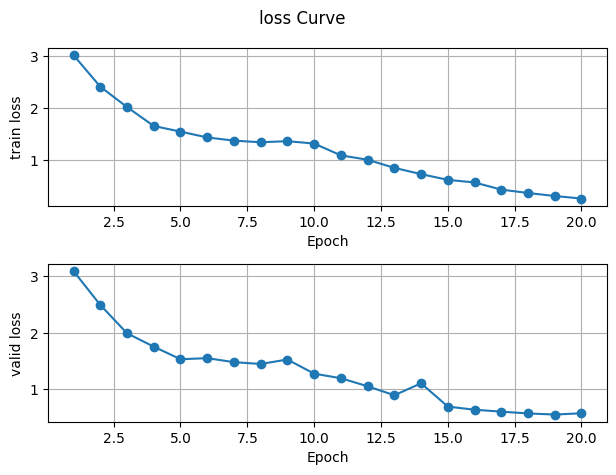

In [ ]:
# 결과 시각화

plot_loss_curve(loss_history, metric="loss", overlap=False)

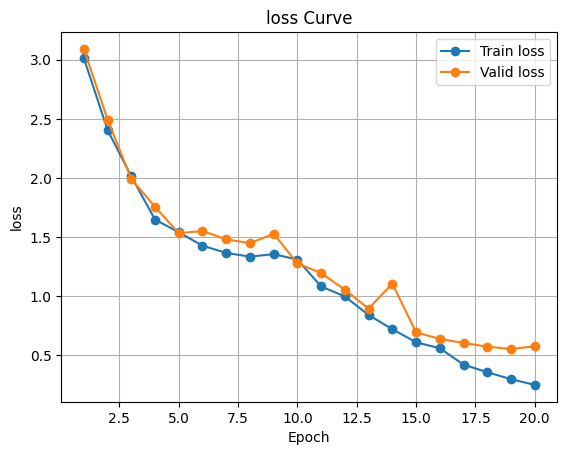

In [ ]:
plot_loss_curve(loss_history, metric="loss", overlap=True)

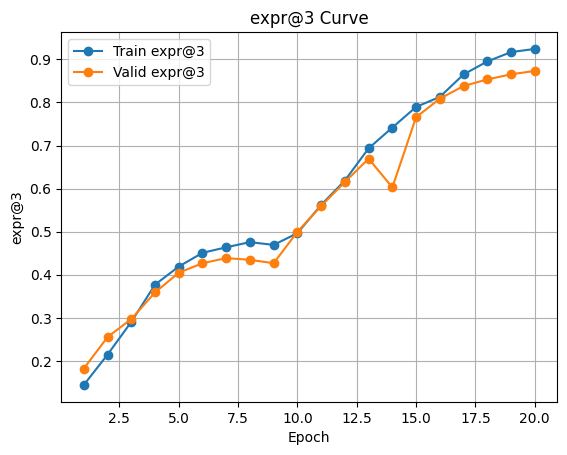

In [ ]:
plot_loss_curve(loss_history, metric="expr@3", overlap=True)

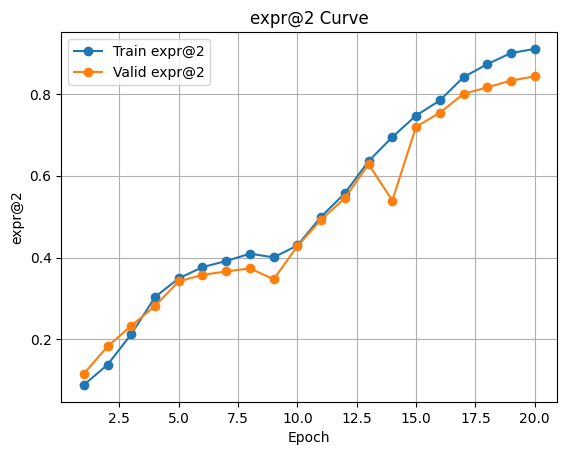

In [ ]:
plot_loss_curve(loss_history, metric="expr@2", overlap=True)

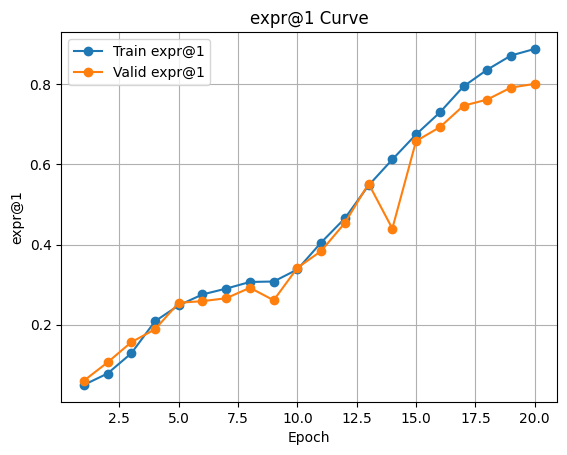

In [ ]:
plot_loss_curve(loss_history, metric="expr@1", overlap=True)

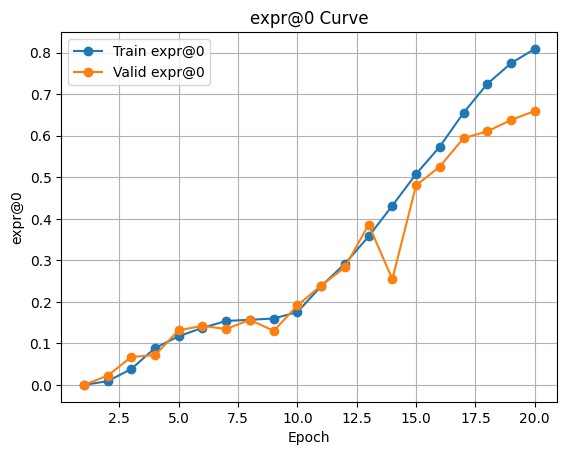

In [ ]:
plot_loss_curve(loss_history, metric="expr@0", overlap=True)

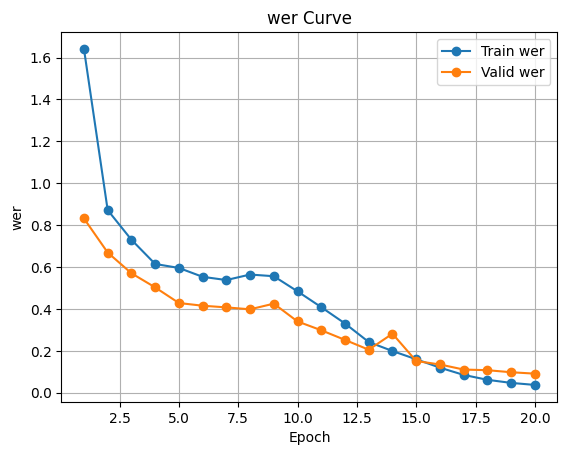

In [ ]:
plot_loss_curve(loss_history, metric="wer", overlap=True)

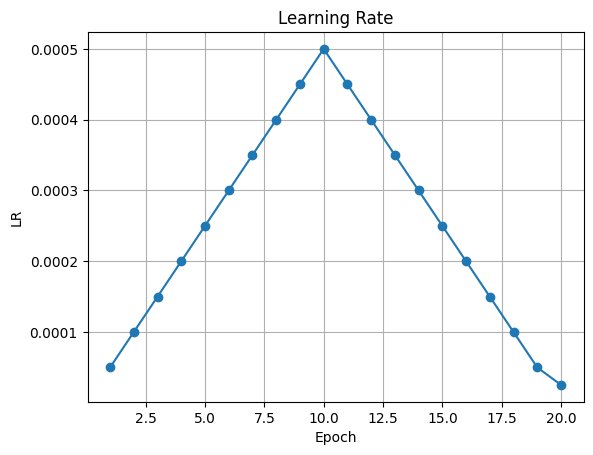

In [ ]:
train = loss_history["Train"]

epochs = []
lr = []
for i, history in enumerate(train):
    lr_list = history["lr"]
    epochs.append(i+1)
    lr.append(lr_list[0])

plt.plot(epochs, lr, marker='o')
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.grid(True)
plt.title("Learning Rate")
plt.show()

# Test
- todo: 지금 저장하는 expr은 배치별 평균값이므로 실제 논문에서 언급되는, 다른 모델과 비교하기 위한 expr 척도로는 활용 불가능함 -> 평균 expr이 아니라, 전체 테스트 데이터에 대한 exact match를 count해서 데이터셋 크기로 나눠서 비교할 수 있게 수정해야함

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=CFG["pad_idx"])

def test(model, test_loader, criterion, device="cuda"):

    eos_idx = CFG["eos_idx"]
    model.eval()

    total_loss = 0.0
    total_expr_0, total_expr_1, total_expr_2, total_expr_3 = 0.0, 0.0, 0.0, 0.0
    total_wer = 0.0
    num_batches = 0

    loop = tqdm(test_loader, leave=True)

    for i, batch in enumerate(loop):
        loop.set_description(f"[Test] batch:{i}/{len(test_loader)}")

        imgs = batch["image"].to(device)
        labels = batch["formula"].to(device)

        pred = model(imgs, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
        labels = labels[:, 1:]                  # sos부분은 제외: (B,T) => (B,T-1)

        loss = criterion(pred.transpose(1,2), labels)  # nn.CrossEntropyLoss() input shape 규칙에 따라 (B,V,T-1)로 pred가 와야하므로 맞춰줌
        pred_tokens = pred.argmax(dim=-1)              # (B,T-1,V) -> (B,T-1)

        expr_0 = float(exprate_k(preds=pred_tokens, targets=labels, k=0, eos_idx=eos_idx))
        expr_1 = float(exprate_k(preds=pred_tokens, targets=labels, k=1, eos_idx=eos_idx))
        expr_2 = float(exprate_k(preds=pred_tokens, targets=labels, k=2, eos_idx=eos_idx))
        expr_3 = float(exprate_k(preds=pred_tokens, targets=labels, k=3, eos_idx=eos_idx))
        wer = float(WER(preds=pred_tokens, targets=labels, eos_idx=eos_idx))

        total_loss += float(loss.item())
        total_expr_0 += expr_0
        total_expr_1 += expr_1
        total_expr_2 += expr_2
        total_expr_3 += expr_3
        total_wer += wer
        num_batches += 1

        loop.set_postfix(loss=loss.item(), expr0=expr_0, expr1=expr_1, expr2=expr_2, expr3=expr_3, wer=wer)

    avg_loss = total_loss / num_batches
    avg_expr_0 = total_expr_0 / num_batches
    avg_expr_1 = total_expr_1 / num_batches
    avg_expr_2 = total_expr_2 / num_batches
    avg_expr_3 = total_expr_3 / num_batches
    avg_wer = total_wer / num_batches

    return avg_loss, avg_expr_0, avg_expr_1, avg_expr_2, avg_expr_3, avg_wer

In [ ]:
# best_model.pth 가져오기

model = SWIN().to(DEVICE)
model.load_state_dict(torch.load(CFG["paths"]["best_ckpt"])["model"])

<All keys matched successfully>

In [ ]:
# 테스트 및 테스트 결과 구글스프레드시트에 저장

from tqdm import tqdm

test_loaders = [crohme_testloader_2014, crohme_testloader_2016, crohme_testloader_2019,
                cropme_testloader_2014, cropme_testloader_2016, cropme_testloader_2019,
                im2latex_hme_testloader, im2latex_pme_testloader]

test_dataset_names = ["CROHME_2014", "CROHME_2016", "CROHME_2019", "CROPME_2014", "CROPME_2016", "CROPME_2019", "IM2LATEX_HME", "IM2LATEX_PME"]

val_dict = {"loss": [],
            "expr@0": [],
            "expr@1": [],
            "expr@2": [],
            "expr@3": [],
            "wer": []}

for i, test_loader in enumerate(test_loaders):
    test_dataset_name = test_dataset_names[i]
    print(test_dataset_name)

    loss, expr0, expr1, expr2, expr3, wer = test(model, test_loader, criterion)
    val_dict["loss"].append(loss)
    val_dict["expr@0"].append(expr0)
    val_dict["expr@1"].append(expr1)
    val_dict["expr@2"].append(expr2)
    val_dict["expr@3"].append(expr3)
    val_dict["wer"].append(wer)


save_test_result(CFG["experiment_name"], val_dict)

CROHME_2014


[Test] batch:985/986: 100%|██████████| 986/986 [02:51<00:00,  5.74it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=2.9, wer=0.74]


CROHME_2016


[Test] batch:1146/1147: 100%|██████████| 1147/1147 [03:32<00:00,  5.39it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=3.89, wer=0.681]


CROHME_2019


...

[Test] batch:1198/1199: 100%|██████████| 1199/1199 [04:25<00:00,  4.52it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=5.13, wer=0.933]


IM2LATEX_HME


[Test] batch:945/946: 100%|██████████| 946/946 [05:39<00:00,  2.78it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=5.82, wer=0.848]


IM2LATEX_PME


[Test] batch:945/946: 100%|██████████| 946/946 [05:39<00:00,  2.79it/s, expr0=0, expr1=0, expr2=0, expr3=0, loss=5.74, wer=0.818]


# Prediction 샘플 시각화

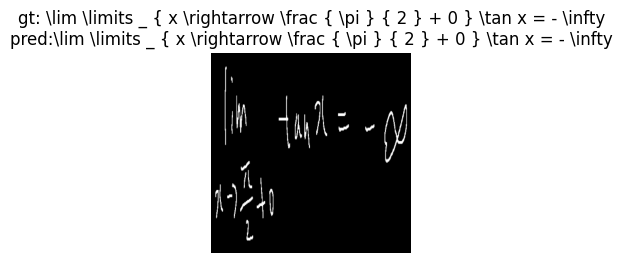

In [ ]:
import numpy as np

batch = next(iter(trainloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

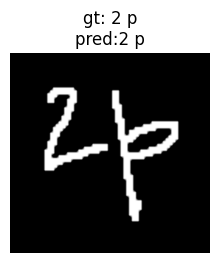

In [ ]:
import numpy as np

batch = next(iter(crohme_testloader_2014))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

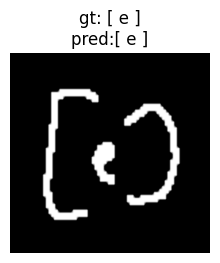

In [ ]:
import numpy as np

batch = next(iter(crohme_testloader_2016))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

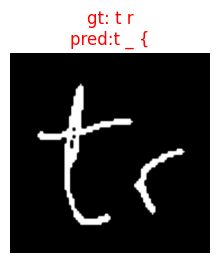

In [ ]:
import numpy as np

batch = next(iter(crohme_testloader_2019))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

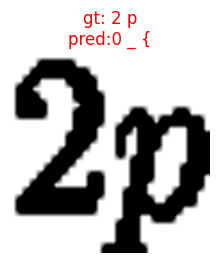

In [ ]:
import numpy as np

batch = next(iter(cropme_testloader_2014))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

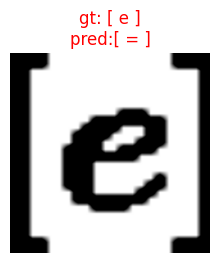

In [ ]:
import numpy as np

batch = next(iter(cropme_testloader_2016))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

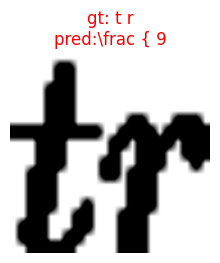

In [ ]:
import numpy as np

batch = next(iter(cropme_testloader_2019))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

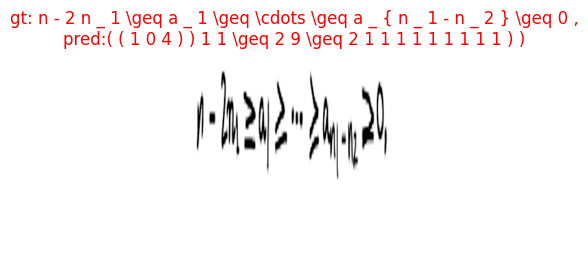

In [ ]:
import numpy as np

batch = next(iter(im2latex_hme_testloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)

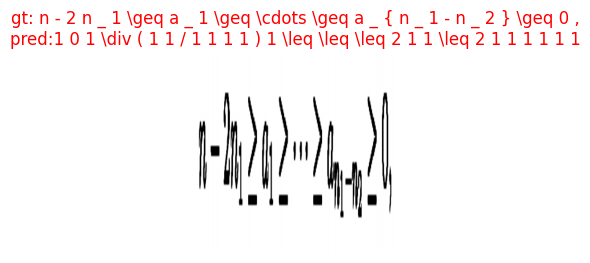

In [ ]:
import numpy as np

batch = next(iter(im2latex_pme_testloader))
images = batch['image'].to(DEVICE)
labels = batch['formula'].to(DEVICE)
y_hats = model(images, labels, is_train=False, teacher_forcing_ratio=0.0)  # (B,T-1,V)
y_hats = torch.argmax(y_hats, axis=-1)
plot_dataset(images, labels, grid_width=1, grid_height=1, figure_width=1, figure_height=1, y_hats=y_hats, vocab=vocab)